<a href="https://colab.research.google.com/github/Fidyaayu/Project-4_Klasifikasi-Mikrobiom-Usus-Anak-ASD/blob/main/Analisis_Mikrobiom_Usus_Anak_ASD_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#DATA UNDERSTANDING

In [ ]:
# STEP 1.1 — Install dan import library
# Proses ini menyiapkan library untuk membaca data, mengecek struktur dataset, dan membuat visualisasi eksploratif.

!pip -q install openpyxl

import os
import re
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.max_colwidth", 150)

RANDOM_STATE = 42

print("Library siap digunakan.")

Library siap digunakan.


In [ ]:
# STEP 1.2 — Mount Google Drive
# Proses ini menghubungkan Google Colab dengan Google Drive agar dataset dapat dibaca langsung dari folder penyimpanan.

drive.mount("/content/drive")

print("Google Drive berhasil terhubung.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive berhasil terhubung.


In [ ]:
# STEP 1.3 — Cek isi folder dataset
# Proses ini menampilkan daftar file dalam folder agar path dan nama file tidak salah.

folder_path = "/content/drive/MyDrive/MAGANG/artikel/analisis perilaku anak autis"

print("Daftar file dalam folder:")
for file in os.listdir(folder_path):
    print(file)

Daftar file dalam folder:
ASD meta abundance.csv
Untitled0.ipynb
Toddler Autism dataset July 2018.csv
Untitled1.ipynb
Untitled2.ipynb
output_ml_asd


In [ ]:
# STEP 1.4 — Load dataset abundance
# Proses ini membaca file abundance mikrobiom dari Google Drive ke dalam DataFrame pandas.

file_path = "/content/drive/MyDrive/MAGANG/artikel/analisis perilaku anak autis/ASD meta abundance.csv"

df_raw = pd.read_csv(file_path)

print("Dataset berhasil dibaca.")
print("Nama file:", os.path.basename(file_path))
print("Shape awal:", df_raw.shape)

display(df_raw.head())

Dataset berhasil dibaca.
Nama file: ASD meta abundance.csv
Shape awal: (5619, 61)


,Taxonomy,A3,A5,A6,A9,A31,A51,A52,A53,A54,A59,A67,A68,A69,A71,A73,A76,A78,A87,A89,A93,A101,A109,A113,A114,A115,A142,A144,A149,A164,A165,B1,B2,B3,B5,B6,B7,B8,B13,B14,B28,B29,B36,B37,B94,B99,B103,B106,B111,B114,B115,B120,B127,B132,B141,B142,B143,B152,B156,B158,B164
0,g__Faecalibacterium;s__Faecalibacterium prausnitzii,4988,5060,2905,5745,4822,3889,4646,6337,5064,6359,3194,4486,3807,6208,3008,5628,5732,5240,3616,3355,3833,3771,5489,6762,3045,6205,6048,5418,5120,8504,4269,4397,4499,6126,7020,5404,4404,5811,3360,4141,2880,3805,4168,4543,2804,5728,3827,6030,4950,4749,4471,5868,6561,4910,4492,2812,5303,4205,3430,4563
1,g__Hungatella;s__Hungatella hathewayi,5803,5612,4109,1432,2652,4175,3891,894,4903,2970,4029,1266,4822,1635,4761,1366,1867,2065,4777,5954,6849,4390,2091,1638,4613,2601,1892,3267,2294,2978,1217,6238,2325,5004,2829,2192,2921,4303,2793,3671,5350,4566,3984,5597,5191,2204,5523,1556,4983,5993,2126,4429,2598,4222,4925,5753,1261,1822,2478,4868
2,g__Clostridium;s__uncultured Clostridium sp.,3793,2795,1355,5558,5383,3505,5541,4429,4121,3258,1901,2940,3820,5118,1582,4168,3831,3464,2942,3291,4586,1014,4100,4336,2301,6372,4020,3511,4328,3906,3853,4624,3842,4399,3916,3355,5165,4453,1999,3974,1185,3895,2710,3425,1559,4902,3016,6066,5082,3764,4085,6041,6188,3960,4403,2841,2746,3808,3856,3211
3,g__Butyricimonas;s__Butyricimonas virosa,64,1385,725,1553,40,53,33,175,58,1636,1170,80,59,77,1364,67,63,7,999,39,3285,30,54,1168,50,38,49,27,1685,838,1624,1,703,43,46,1505,32,1474,2,52,4,5,43,1449,5,36,34,37,113,46,2065,21,27,55,35,8,884,13,3,218
4,g__Alistipes;s__Alistipes indistinctus,15,20,723,620,3261,43,83,37,43,1114,2531,207,59,50,55,1194,68,49,979,10,3159,61,2606,2821,21,2276,3,34,2681,2103,2452,3,819,2761,691,2768,25,1095,13,4,4,6,356,2380,23,3089,33,2052,2801,2,90,22,30,1027,2641,4,1587,2223,6,1473


In [ ]:
# STEP 1.5 — Cek struktur awal dataset
# Proses ini memeriksa jumlah baris, jumlah kolom, nama kolom, tipe data, dan contoh isi dataset sebelum transpose.

print("Shape dataset awal:", df_raw.shape)

print("\nNama 20 kolom pertama:")
print(df_raw.columns.tolist()[:20])

print("\nInformasi dataset:")
df_raw.info()

print("\nPreview data:")
display(df_raw.head())

Shape dataset awal: (5619, 61)

Nama 20 kolom pertama:
['Taxonomy', 'A3', 'A5', 'A6', 'A9', 'A31', 'A51', 'A52', 'A53', 'A54', 'A59', 'A67', 'A68', 'A69', 'A71', 'A73', 'A76', 'A78', 'A87', 'A89']

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5619 entries, 0 to 5618
Data columns (total 61 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Taxonomy  5619 non-null   object
 1   A3        5619 non-null   int64 
 2   A5        5619 non-null   int64 
 3   A6        5619 non-null   int64 
 4   A9        5619 non-null   int64 
 5   A31       5619 non-null   int64 
 6   A51       5619 non-null   int64 
 7   A52       5619 non-null   int64 
 8   A53       5619 non-null   int64 
 9   A54       5619 non-null   int64 
 10  A59       5619 non-null   int64 
 11  A67       5619 non-null   int64 
 12  A68       5619 non-null   int64 
 13  A69       5619 non-null   int64 
 14  A71       5619 non-null   int64 
 15  A73       5619 non-null  

,Taxonomy,A3,A5,A6,A9,A31,A51,A52,A53,A54,A59,A67,A68,A69,A71,A73,A76,A78,A87,A89,A93,A101,A109,A113,A114,A115,A142,A144,A149,A164,A165,B1,B2,B3,B5,B6,B7,B8,B13,B14,B28,B29,B36,B37,B94,B99,B103,B106,B111,B114,B115,B120,B127,B132,B141,B142,B143,B152,B156,B158,B164
0,g__Faecalibacterium;s__Faecalibacterium prausnitzii,4988,5060,2905,5745,4822,3889,4646,6337,5064,6359,3194,4486,3807,6208,3008,5628,5732,5240,3616,3355,3833,3771,5489,6762,3045,6205,6048,5418,5120,8504,4269,4397,4499,6126,7020,5404,4404,5811,3360,4141,2880,3805,4168,4543,2804,5728,3827,6030,4950,4749,4471,5868,6561,4910,4492,2812,5303,4205,3430,4563
1,g__Hungatella;s__Hungatella hathewayi,5803,5612,4109,1432,2652,4175,3891,894,4903,2970,4029,1266,4822,1635,4761,1366,1867,2065,4777,5954,6849,4390,2091,1638,4613,2601,1892,3267,2294,2978,1217,6238,2325,5004,2829,2192,2921,4303,2793,3671,5350,4566,3984,5597,5191,2204,5523,1556,4983,5993,2126,4429,2598,4222,4925,5753,1261,1822,2478,4868
2,g__Clostridium;s__uncultured Clostridium sp.,3793,2795,1355,5558,5383,3505,5541,4429,4121,3258,1901,2940,3820,5118,1582,4168,3831,3464,2942,3291,4586,1014,4100,4336,2301,6372,4020,3511,4328,3906,3853,4624,3842,4399,3916,3355,5165,4453,1999,3974,1185,3895,2710,3425,1559,4902,3016,6066,5082,3764,4085,6041,6188,3960,4403,2841,2746,3808,3856,3211
3,g__Butyricimonas;s__Butyricimonas virosa,64,1385,725,1553,40,53,33,175,58,1636,1170,80,59,77,1364,67,63,7,999,39,3285,30,54,1168,50,38,49,27,1685,838,1624,1,703,43,46,1505,32,1474,2,52,4,5,43,1449,5,36,34,37,113,46,2065,21,27,55,35,8,884,13,3,218
4,g__Alistipes;s__Alistipes indistinctus,15,20,723,620,3261,43,83,37,43,1114,2531,207,59,50,55,1194,68,49,979,10,3159,61,2606,2821,21,2276,3,34,2681,2103,2452,3,819,2761,691,2768,25,1095,13,4,4,6,356,2380,23,3089,33,2052,2801,2,90,22,30,1027,2641,4,1587,2223,6,1473


In [ ]:
# STEP 1.6 — Menentukan kolom taxonomy
# Proses ini memastikan kolom pertama diperlakukan sebagai nama taxonomy atau nama bakteri.

taxonomy_col = df_raw.columns[0]

df_raw = df_raw.rename(columns={taxonomy_col: "Taxonomy"})

print("Kolom taxonomy yang digunakan: Taxonomy")

display(df_raw.head())

Kolom taxonomy yang digunakan: Taxonomy


,Taxonomy,A3,A5,A6,A9,A31,A51,A52,A53,A54,A59,A67,A68,A69,A71,A73,A76,A78,A87,A89,A93,A101,A109,A113,A114,A115,A142,A144,A149,A164,A165,B1,B2,B3,B5,B6,B7,B8,B13,B14,B28,B29,B36,B37,B94,B99,B103,B106,B111,B114,B115,B120,B127,B132,B141,B142,B143,B152,B156,B158,B164
0,g__Faecalibacterium;s__Faecalibacterium prausnitzii,4988,5060,2905,5745,4822,3889,4646,6337,5064,6359,3194,4486,3807,6208,3008,5628,5732,5240,3616,3355,3833,3771,5489,6762,3045,6205,6048,5418,5120,8504,4269,4397,4499,6126,7020,5404,4404,5811,3360,4141,2880,3805,4168,4543,2804,5728,3827,6030,4950,4749,4471,5868,6561,4910,4492,2812,5303,4205,3430,4563
1,g__Hungatella;s__Hungatella hathewayi,5803,5612,4109,1432,2652,4175,3891,894,4903,2970,4029,1266,4822,1635,4761,1366,1867,2065,4777,5954,6849,4390,2091,1638,4613,2601,1892,3267,2294,2978,1217,6238,2325,5004,2829,2192,2921,4303,2793,3671,5350,4566,3984,5597,5191,2204,5523,1556,4983,5993,2126,4429,2598,4222,4925,5753,1261,1822,2478,4868
2,g__Clostridium;s__uncultured Clostridium sp.,3793,2795,1355,5558,5383,3505,5541,4429,4121,3258,1901,2940,3820,5118,1582,4168,3831,3464,2942,3291,4586,1014,4100,4336,2301,6372,4020,3511,4328,3906,3853,4624,3842,4399,3916,3355,5165,4453,1999,3974,1185,3895,2710,3425,1559,4902,3016,6066,5082,3764,4085,6041,6188,3960,4403,2841,2746,3808,3856,3211
3,g__Butyricimonas;s__Butyricimonas virosa,64,1385,725,1553,40,53,33,175,58,1636,1170,80,59,77,1364,67,63,7,999,39,3285,30,54,1168,50,38,49,27,1685,838,1624,1,703,43,46,1505,32,1474,2,52,4,5,43,1449,5,36,34,37,113,46,2065,21,27,55,35,8,884,13,3,218
4,g__Alistipes;s__Alistipes indistinctus,15,20,723,620,3261,43,83,37,43,1114,2531,207,59,50,55,1194,68,49,979,10,3159,61,2606,2821,21,2276,3,34,2681,2103,2452,3,819,2761,691,2768,25,1095,13,4,4,6,356,2380,23,3089,33,2052,2801,2,90,22,30,1027,2641,4,1587,2223,6,1473


In [ ]:
# STEP 1.7 — Cleaning awal sebelum transpose
# Proses ini membersihkan teks taxonomy dan memastikan seluruh kolom sampel berbentuk numerik.

df_clean = df_raw.copy()

df_clean["Taxonomy"] = df_clean["Taxonomy"].astype(str).str.strip()

df_clean = df_clean[
    ~df_clean["Taxonomy"].str.lower().isin(["", "nan", "none", "null"])
].copy()

sample_cols = [col for col in df_clean.columns if col != "Taxonomy"]

for col in sample_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

print("Shape setelah cleaning awal:", df_clean.shape)

display(df_clean.head())

Shape setelah cleaning awal: (5619, 61)


,Taxonomy,A3,A5,A6,A9,A31,A51,A52,A53,A54,A59,A67,A68,A69,A71,A73,A76,A78,A87,A89,A93,A101,A109,A113,A114,A115,A142,A144,A149,A164,A165,B1,B2,B3,B5,B6,B7,B8,B13,B14,B28,B29,B36,B37,B94,B99,B103,B106,B111,B114,B115,B120,B127,B132,B141,B142,B143,B152,B156,B158,B164
0,g__Faecalibacterium;s__Faecalibacterium prausnitzii,4988,5060,2905,5745,4822,3889,4646,6337,5064,6359,3194,4486,3807,6208,3008,5628,5732,5240,3616,3355,3833,3771,5489,6762,3045,6205,6048,5418,5120,8504,4269,4397,4499,6126,7020,5404,4404,5811,3360,4141,2880,3805,4168,4543,2804,5728,3827,6030,4950,4749,4471,5868,6561,4910,4492,2812,5303,4205,3430,4563
1,g__Hungatella;s__Hungatella hathewayi,5803,5612,4109,1432,2652,4175,3891,894,4903,2970,4029,1266,4822,1635,4761,1366,1867,2065,4777,5954,6849,4390,2091,1638,4613,2601,1892,3267,2294,2978,1217,6238,2325,5004,2829,2192,2921,4303,2793,3671,5350,4566,3984,5597,5191,2204,5523,1556,4983,5993,2126,4429,2598,4222,4925,5753,1261,1822,2478,4868
2,g__Clostridium;s__uncultured Clostridium sp.,3793,2795,1355,5558,5383,3505,5541,4429,4121,3258,1901,2940,3820,5118,1582,4168,3831,3464,2942,3291,4586,1014,4100,4336,2301,6372,4020,3511,4328,3906,3853,4624,3842,4399,3916,3355,5165,4453,1999,3974,1185,3895,2710,3425,1559,4902,3016,6066,5082,3764,4085,6041,6188,3960,4403,2841,2746,3808,3856,3211
3,g__Butyricimonas;s__Butyricimonas virosa,64,1385,725,1553,40,53,33,175,58,1636,1170,80,59,77,1364,67,63,7,999,39,3285,30,54,1168,50,38,49,27,1685,838,1624,1,703,43,46,1505,32,1474,2,52,4,5,43,1449,5,36,34,37,113,46,2065,21,27,55,35,8,884,13,3,218
4,g__Alistipes;s__Alistipes indistinctus,15,20,723,620,3261,43,83,37,43,1114,2531,207,59,50,55,1194,68,49,979,10,3159,61,2606,2821,21,2276,3,34,2681,2103,2452,3,819,2761,691,2768,25,1095,13,4,4,6,356,2380,23,3089,33,2052,2801,2,90,22,30,1027,2641,4,1587,2223,6,1473


In [ ]:
# STEP 1.8 — Cek missing value sebelum transpose
# Proses ini mengecek apakah ada nilai kosong pada tabel abundance sebelum data diubah formatnya.

missing_before = df_clean.isnull().sum()
missing_before = missing_before[missing_before > 0].sort_values(ascending=False)

print("Jumlah kolom dengan missing value sebelum transpose:", len(missing_before))

display(missing_before.head(20))

Jumlah kolom dengan missing value sebelum transpose: 0


,0


In [ ]:
# STEP 1.9 — Cek nilai negatif
# Proses ini memastikan tidak ada nilai abundance negatif karena data count mikrobiom seharusnya tidak bernilai negatif.

abundance_only_before = df_clean.drop(columns=["Taxonomy"])

negative_count_before = (abundance_only_before < 0).sum().sum()

print("Jumlah nilai negatif sebelum transpose:", negative_count_before)

Jumlah nilai negatif sebelum transpose: 0


In [ ]:
# STEP 1.10 — Cek dan gabungkan taxonomy duplikat
# Proses ini memastikan setiap taxonomy hanya menjadi satu fitur dengan cara menjumlahkan abundance jika ada taxonomy yang sama.

duplicate_taxa = df_clean["Taxonomy"].duplicated().sum()

print("Jumlah taxonomy duplikat:", duplicate_taxa)

df_clean = df_clean.groupby("Taxonomy", as_index=False).sum()

print("Shape setelah taxonomy duplikat digabung:", df_clean.shape)

display(df_clean.head())

Jumlah taxonomy duplikat: 0
Shape setelah taxonomy duplikat digabung: (5619, 61)


,Taxonomy,A3,A5,A6,A9,A31,A51,A52,A53,A54,A59,A67,A68,A69,A71,A73,A76,A78,A87,A89,A93,A101,A109,A113,A114,A115,A142,A144,A149,A164,A165,B1,B2,B3,B5,B6,B7,B8,B13,B14,B28,B29,B36,B37,B94,B99,B103,B106,B111,B114,B115,B120,B127,B132,B141,B142,B143,B152,B156,B158,B164
0,g__Absidia;s__Absidia glauca,1,1,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,1,0,0,1,0,1,1,0,0,1,0,0,1,0,0,0,1,0,0,1,1,0,0,0,1,0,1,1,1,1,0,1,0,1,1,0,1,1,0,1
1,g__Acaryochloris;s__Acaryochloris sp. CCMEE 5410,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0
2,g__Acetanaerobacterium;s__Acetanaerobacterium elongatum,10,12,8,18,12,6,7,16,33,27,3,7,24,21,8,15,14,21,19,14,15,3,13,25,3,33,14,15,12,28,10,12,27,36,5,20,9,24,2,2,4,2,8,16,8,20,24,22,33,16,28,18,17,11,11,7,9,22,11,11
3,g__Acetivibrio;s__Acetivibrio cellulolyticus,2,1,3,11,9,6,4,3,7,3,1,6,4,6,2,6,2,6,5,1,4,4,5,10,2,9,6,7,4,5,2,2,2,10,1,2,4,7,1,0,0,1,0,6,3,4,2,5,14,0,4,8,3,8,5,0,1,7,2,4
4,g__Acetivibrio;s__Acetivibrio ethanolgignens,20,33,32,48,58,38,58,73,37,42,31,19,32,49,18,23,41,28,33,29,58,20,41,48,28,64,69,37,59,49,36,29,40,57,29,29,43,43,10,33,13,20,24,31,15,26,39,73,48,49,24,74,67,29,30,31,28,23,24,26


In [ ]:
# STEP 1.11 — Transpose dataset
# Proses ini mengubah format data dari baris=bakteri menjadi baris=sampel dan kolom=bakteri.

df_transposed = df_clean.set_index("Taxonomy").T

df_transposed.index.name = "Sample_ID"

df_transposed = df_transposed.reset_index()

df_transposed.columns.name = None

print("Shape sebelum transpose:", df_clean.shape)
print("Shape setelah transpose:", df_transposed.shape)

display(df_transposed.head())

Shape sebelum transpose: (5619, 61)
Shape setelah transpose: (60, 5620)


,Sample_ID,g__Absidia;s__Absidia glauca,g__Acaryochloris;s__Acaryochloris sp. CCMEE 5410,g__Acetanaerobacterium;s__Acetanaerobacterium elongatum,g__Acetivibrio;s__Acetivibrio cellulolyticus,g__Acetivibrio;s__Acetivibrio ethanolgignens,g__Acetoanaerobium;s__Acetoanaerobium sticklandii,g__Acetobacter;s__Acetobacter malorum,g__Acetobacter;s__Acetobacter sp. CAG:267,g__Acetobacter;s__Acetobacter sp. CAG:977,g__Acetobacterium;s__Acetobacterium bakii,g__Acetobacterium;s__Acetobacterium dehalogenans,g__Acetobacterium;s__Acetobacterium wieringae,g__Acetobacterium;s__Acetobacterium woodii,g__Acetohalobium;s__Acetohalobium arabaticum,g__Acetomicrobium;s__Acetomicrobium hydrogeniformans,g__Acetomicrobium;s__Acetomicrobium mobile,g__Acetonema;s__Acetonema longum,g__Acholeplasma;s__Acholeplasma axanthum,g__Acholeplasma;s__Acholeplasma brassicae,g__Acholeplasma;s__Acholeplasma equifetale,g__Acholeplasma;s__Acholeplasma granularum,g__Acholeplasma;s__Acholeplasma hippikon,g__Acholeplasma;s__Acholeplasma laidlawii,g__Acholeplasma;s__Acholeplasma modicum,g__Acholeplasma;s__Acholeplasma oculi,g__Acholeplasma;s__Acholeplasma palmae,g__Acholeplasma;s__Acholeplasma sp. CAG:878,g__Achromatium;s__Achromatium sp. WMS2,g__Achromatium;s__Candidatus Achromatium palustre,g__Achromobacter;s__Achromobacter piechaudii,g__Achromobacter;s__Achromobacter sp. 2789STDY5608607,g__Achromobacter;s__Achromobacter sp. 2789STDY5608609,g__Achromobacter;s__Achromobacter sp. ATCC35328,g__Achromobacter;s__Achromobacter xylosoxidans,g__Acidaminobacter;s__Acidaminobacter hydrogenoformans,g__Acidaminococcus;s__Acidaminococcus fermentans,g__Acidaminococcus;s__Acidaminococcus intestini,g__Acidaminococcus;s__Acidaminococcus intestini CAG:325,g__Acidaminococcus;s__Acidaminococcus sp. BV3L6,g__Acidaminococcus;s__Acidaminococcus sp. CAG:542,g__Acidaminococcus;s__Acidaminococcus sp. CAG:917,g__Acidaminococcus;s__Acidaminococcus sp. D21,g__Acidaminococcus;s__Acidaminococcus sp. HPA0509,g__Acidaminococcus;s__Acidaminococcus sp. Marseille-P2764,g__Acidibacillus;s__Acidibacillus ferrooxidans,g__Acidiferrobacter;s__Acidiferrobacter thiooxydans,g__Acidihalobacter;s__Acidihalobacter prosperus,g__Acidiphilium;s__Acidiphilium angustum,g__Acidiphilium;s__Acidiphilium sp. CAG:727,g__Acidiplasma;s__Acidiplasma cupricumulans,g__Acidipropionibacterium;s__Acidipropionibacterium acidipropionici,g__Acidithiobacillus;s__Acidithiobacillus caldus,g__Acidithiobacillus;s__Acidithiobacillus ferrivorans,g__Acidithiobacillus;s__Acidithiobacillus thiooxidans,g__Acidithrix;s__Acidithrix ferrooxidans,g__Acidobacterium;s__Acidobacterium ailaaui,g__Acidobacterium;s__Acidobacterium capsulatum,g__Acidocella;s__Acidocella aminolytica,g__Acidovorax;s__Acidovorax citrulli,...,g__Vibrio;s__Vibrio sp. ECSMB14105,g__Vibrio;s__Vibrio sp. J2-31,g__Vibrio;s__Vibrio sp. MEBiC08052,g__Vibrio;s__Vibrio sp. OY15,g__Vibrio;s__Vibrio splendidus,g__Vibrio;s__Vibrio tasmaniensis,g__Vibrio;s__Vibrio tritonius,g__Vibrio;s__Vibrio variabilis,g__Vibrio;s__Vibrio vulnificus,g__Vibrio;s__Vibrio xiamenensis,g__Vibrio;s__uncultured Vibrio sp.,g__Virgibacillus;s__Virgibacillus alimentarius,g__Virgibacillus;s__Virgibacillus pantothenticus,g__Virgibacillus;s__Virgibacillus salinus,g__Virgibacillus;s__Virgibacillus soli,g__Virgibacillus;s__Virgibacillus sp. SK-1,g__Virgibacillus;s__Virgibacillus sp. Vm-5,g__Vitellibacter;s__Vitellibacter soesokkakensis,g__Vitellibacter;s__Vitellibacter vladivostokensis,g__Vulcanibacillus;s__Vulcanibacillus modesticaldus,g__Vulgatibacter;s__Vulgatibacter incomptus,g__Waddlia;s__Waddlia chondrophila,g__Weeksella;s__Weeksella sp. FF8,g__Weeksella;s__Weeksella sp. HMSC059D05,g__Weeksella;s__Weeksella virosa,g__Weissella;s__Weissella bombi,g__Weissella;s__Weissella cibaria,g__Wenyingzhuangia;s__Wenyingzhuangia fucanilytica,g__Wenzhouxiangella;s__Wenzhouxiangella marina,g__Williamsia;s__Williamsia sp. D3,g__Winogradskyella;s__Winogradskyella psychrotolerans,g__Winogradskyella;s__Winogradskyella sp. PG-2,g__Winograd

In [ ]:
# STEP 1.12 — Cek struktur setelah transpose
# Proses ini memastikan dataset sudah berbentuk baris=sampel dan kolom=fitur bakteri.

print("Shape dataset setelah transpose:", df_transposed.shape)

print("\nPreview setelah transpose:")
display(df_transposed.head())

print("\nInformasi dataset setelah transpose:")
df_transposed.info()

Shape dataset setelah transpose: (60, 5620)

Preview setelah transpose:


,Sample_ID,g__Absidia;s__Absidia glauca,g__Acaryochloris;s__Acaryochloris sp. CCMEE 5410,g__Acetanaerobacterium;s__Acetanaerobacterium elongatum,g__Acetivibrio;s__Acetivibrio cellulolyticus,g__Acetivibrio;s__Acetivibrio ethanolgignens,g__Acetoanaerobium;s__Acetoanaerobium sticklandii,g__Acetobacter;s__Acetobacter malorum,g__Acetobacter;s__Acetobacter sp. CAG:267,g__Acetobacter;s__Acetobacter sp. CAG:977,g__Acetobacterium;s__Acetobacterium bakii,g__Acetobacterium;s__Acetobacterium dehalogenans,g__Acetobacterium;s__Acetobacterium wieringae,g__Acetobacterium;s__Acetobacterium woodii,g__Acetohalobium;s__Acetohalobium arabaticum,g__Acetomicrobium;s__Acetomicrobium hydrogeniformans,g__Acetomicrobium;s__Acetomicrobium mobile,g__Acetonema;s__Acetonema longum,g__Acholeplasma;s__Acholeplasma axanthum,g__Acholeplasma;s__Acholeplasma brassicae,g__Acholeplasma;s__Acholeplasma equifetale,g__Acholeplasma;s__Acholeplasma granularum,g__Acholeplasma;s__Acholeplasma hippikon,g__Acholeplasma;s__Acholeplasma laidlawii,g__Acholeplasma;s__Acholeplasma modicum,g__Acholeplasma;s__Acholeplasma oculi,g__Acholeplasma;s__Acholeplasma palmae,g__Acholeplasma;s__Acholeplasma sp. CAG:878,g__Achromatium;s__Achromatium sp. WMS2,g__Achromatium;s__Candidatus Achromatium palustre,g__Achromobacter;s__Achromobacter piechaudii,g__Achromobacter;s__Achromobacter sp. 2789STDY5608607,g__Achromobacter;s__Achromobacter sp. 2789STDY5608609,g__Achromobacter;s__Achromobacter sp. ATCC35328,g__Achromobacter;s__Achromobacter xylosoxidans,g__Acidaminobacter;s__Acidaminobacter hydrogenoformans,g__Acidaminococcus;s__Acidaminococcus fermentans,g__Acidaminococcus;s__Acidaminococcus intestini,g__Acidaminococcus;s__Acidaminococcus intestini CAG:325,g__Acidaminococcus;s__Acidaminococcus sp. BV3L6,g__Acidaminococcus;s__Acidaminococcus sp. CAG:542,g__Acidaminococcus;s__Acidaminococcus sp. CAG:917,g__Acidaminococcus;s__Acidaminococcus sp. D21,g__Acidaminococcus;s__Acidaminococcus sp. HPA0509,g__Acidaminococcus;s__Acidaminococcus sp. Marseille-P2764,g__Acidibacillus;s__Acidibacillus ferrooxidans,g__Acidiferrobacter;s__Acidiferrobacter thiooxydans,g__Acidihalobacter;s__Acidihalobacter prosperus,g__Acidiphilium;s__Acidiphilium angustum,g__Acidiphilium;s__Acidiphilium sp. CAG:727,g__Acidiplasma;s__Acidiplasma cupricumulans,g__Acidipropionibacterium;s__Acidipropionibacterium acidipropionici,g__Acidithiobacillus;s__Acidithiobacillus caldus,g__Acidithiobacillus;s__Acidithiobacillus ferrivorans,g__Acidithiobacillus;s__Acidithiobacillus thiooxidans,g__Acidithrix;s__Acidithrix ferrooxidans,g__Acidobacterium;s__Acidobacterium ailaaui,g__Acidobacterium;s__Acidobacterium capsulatum,g__Acidocella;s__Acidocella aminolytica,g__Acidovorax;s__Acidovorax citrulli,...,g__Vibrio;s__Vibrio sp. ECSMB14105,g__Vibrio;s__Vibrio sp. J2-31,g__Vibrio;s__Vibrio sp. MEBiC08052,g__Vibrio;s__Vibrio sp. OY15,g__Vibrio;s__Vibrio splendidus,g__Vibrio;s__Vibrio tasmaniensis,g__Vibrio;s__Vibrio tritonius,g__Vibrio;s__Vibrio variabilis,g__Vibrio;s__Vibrio vulnificus,g__Vibrio;s__Vibrio xiamenensis,g__Vibrio;s__uncultured Vibrio sp.,g__Virgibacillus;s__Virgibacillus alimentarius,g__Virgibacillus;s__Virgibacillus pantothenticus,g__Virgibacillus;s__Virgibacillus salinus,g__Virgibacillus;s__Virgibacillus soli,g__Virgibacillus;s__Virgibacillus sp. SK-1,g__Virgibacillus;s__Virgibacillus sp. Vm-5,g__Vitellibacter;s__Vitellibacter soesokkakensis,g__Vitellibacter;s__Vitellibacter vladivostokensis,g__Vulcanibacillus;s__Vulcanibacillus modesticaldus,g__Vulgatibacter;s__Vulgatibacter incomptus,g__Waddlia;s__Waddlia chondrophila,g__Weeksella;s__Weeksella sp. FF8,g__Weeksella;s__Weeksella sp. HMSC059D05,g__Weeksella;s__Weeksella virosa,g__Weissella;s__Weissella bombi,g__Weissella;s__Weissella cibaria,g__Wenyingzhuangia;s__Wenyingzhuangia fucanilytica,g__Wenzhouxiangella;s__Wenzhouxiangella marina,g__Williamsia;s__Williamsia sp. D3,g__Winogradskyella;s__Winogradskyella psychrotolerans,g__Winogradskyella;s__Winogradskyella sp. PG-2,g__Winograd


Informasi dataset setelah transpose:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Columns: 5620 entries, Sample_ID to g__Zunongwangia;s__Zunongwangia profunda
dtypes: int64(5619), object(1)
memory usage: 2.6+ MB


In [ ]:
# STEP 1.13 — Cek missing value setelah transpose
# Proses ini memeriksa apakah ada nilai kosong setelah dataset diubah menjadi format machine learning.

missing_after = df_transposed.isnull().sum()
missing_after = missing_after[missing_after > 0].sort_values(ascending=False)

print("Jumlah kolom dengan missing value setelah transpose:", len(missing_after))

display(missing_after.head(20))

Jumlah kolom dengan missing value setelah transpose: 0


,0


In [ ]:
# STEP 1.14 — Cek duplicate sample
# Proses ini memastikan tidak ada Sample_ID yang muncul lebih dari satu kali.

duplicate_samples = df_transposed["Sample_ID"].duplicated().sum()

print("Jumlah Sample_ID duplikat:", duplicate_samples)

if duplicate_samples > 0:
    display(df_transposed[df_transposed["Sample_ID"].duplicated(keep=False)])

Jumlah Sample_ID duplikat: 0


In [ ]:
# STEP 1.15 — Pisahkan identitas sampel dan fitur bakteri
# Proses ini memisahkan kolom Sample_ID dari fitur bakteri agar identitas sampel tidak ikut menjadi variabel prediktor.

id_col = "Sample_ID"

feature_cols = [col for col in df_transposed.columns if col != id_col]

X_counts = df_transposed[feature_cols].copy()

n_samples = df_transposed.shape[0]
n_features = len(feature_cols)

print("Jumlah sampel:", n_samples)
print("Jumlah fitur bakteri:", n_features)
print("Rasio fitur terhadap sampel:", round(n_features / n_samples, 2))

Jumlah sampel: 60
Jumlah fitur bakteri: 5619
Rasio fitur terhadap sampel: 93.65


In [ ]:
# STEP 1.16 — Cek sparsity
# Proses ini menghitung persentase nilai nol karena data mikrobiom biasanya bersifat sparse.

zero_count = (X_counts == 0).sum().sum()
total_values = X_counts.size
zero_percentage = zero_count / total_values * 100

print("Jumlah nilai nol:", zero_count)
print("Total nilai fitur:", total_values)
print("Persentase nilai nol:", round(zero_percentage, 2), "%")

Jumlah nilai nol: 223765
Total nilai fitur: 337140
Persentase nilai nol: 66.37 %


,Sample_ID,Total_Abundance
0,A3,73596
1,A5,86591
2,A6,58149
3,A9,117425
4,A31,95710


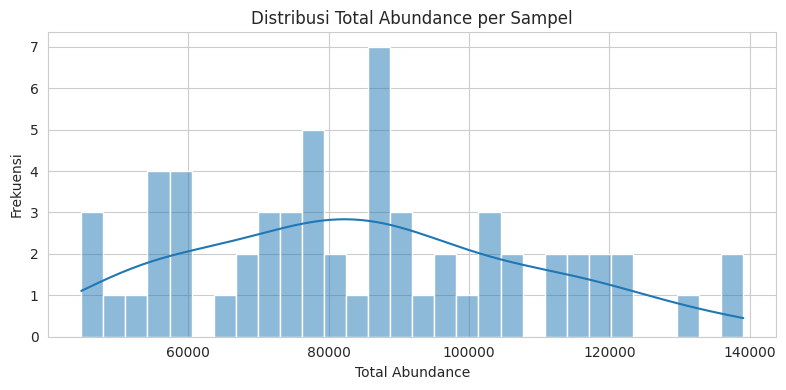

In [ ]:
# STEP 1.17 — Total abundance untuk EDA
# Proses ini menghitung total abundance tiap sampel hanya untuk analisis eksploratif, bukan sebagai fitur model.

df_eda = df_transposed.copy()

df_eda["Total_Abundance"] = X_counts.sum(axis=1)

display(df_eda[["Sample_ID", "Total_Abundance"]].head())

plt.figure(figsize=(8, 4))
sns.histplot(df_eda["Total_Abundance"], bins=30, kde=True)
plt.title("Distribusi Total Abundance per Sampel")
plt.xlabel("Total Abundance")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()

In [ ]:
# STEP 1.18 — Dataset bersih untuk modeling
# Proses ini membuat dataset dasar untuk modeling tanpa kolom Total_Abundance.

df_model_ready = df_transposed.copy()

print("Shape dataset model ready:", df_model_ready.shape)

display(df_model_ready.head())

Shape dataset model ready: (60, 5620)


,Sample_ID,g__Absidia;s__Absidia glauca,g__Acaryochloris;s__Acaryochloris sp. CCMEE 5410,g__Acetanaerobacterium;s__Acetanaerobacterium elongatum,g__Acetivibrio;s__Acetivibrio cellulolyticus,g__Acetivibrio;s__Acetivibrio ethanolgignens,g__Acetoanaerobium;s__Acetoanaerobium sticklandii,g__Acetobacter;s__Acetobacter malorum,g__Acetobacter;s__Acetobacter sp. CAG:267,g__Acetobacter;s__Acetobacter sp. CAG:977,g__Acetobacterium;s__Acetobacterium bakii,g__Acetobacterium;s__Acetobacterium dehalogenans,g__Acetobacterium;s__Acetobacterium wieringae,g__Acetobacterium;s__Acetobacterium woodii,g__Acetohalobium;s__Acetohalobium arabaticum,g__Acetomicrobium;s__Acetomicrobium hydrogeniformans,g__Acetomicrobium;s__Acetomicrobium mobile,g__Acetonema;s__Acetonema longum,g__Acholeplasma;s__Acholeplasma axanthum,g__Acholeplasma;s__Acholeplasma brassicae,g__Acholeplasma;s__Acholeplasma equifetale,g__Acholeplasma;s__Acholeplasma granularum,g__Acholeplasma;s__Acholeplasma hippikon,g__Acholeplasma;s__Acholeplasma laidlawii,g__Acholeplasma;s__Acholeplasma modicum,g__Acholeplasma;s__Acholeplasma oculi,g__Acholeplasma;s__Acholeplasma palmae,g__Acholeplasma;s__Acholeplasma sp. CAG:878,g__Achromatium;s__Achromatium sp. WMS2,g__Achromatium;s__Candidatus Achromatium palustre,g__Achromobacter;s__Achromobacter piechaudii,g__Achromobacter;s__Achromobacter sp. 2789STDY5608607,g__Achromobacter;s__Achromobacter sp. 2789STDY5608609,g__Achromobacter;s__Achromobacter sp. ATCC35328,g__Achromobacter;s__Achromobacter xylosoxidans,g__Acidaminobacter;s__Acidaminobacter hydrogenoformans,g__Acidaminococcus;s__Acidaminococcus fermentans,g__Acidaminococcus;s__Acidaminococcus intestini,g__Acidaminococcus;s__Acidaminococcus intestini CAG:325,g__Acidaminococcus;s__Acidaminococcus sp. BV3L6,g__Acidaminococcus;s__Acidaminococcus sp. CAG:542,g__Acidaminococcus;s__Acidaminococcus sp. CAG:917,g__Acidaminococcus;s__Acidaminococcus sp. D21,g__Acidaminococcus;s__Acidaminococcus sp. HPA0509,g__Acidaminococcus;s__Acidaminococcus sp. Marseille-P2764,g__Acidibacillus;s__Acidibacillus ferrooxidans,g__Acidiferrobacter;s__Acidiferrobacter thiooxydans,g__Acidihalobacter;s__Acidihalobacter prosperus,g__Acidiphilium;s__Acidiphilium angustum,g__Acidiphilium;s__Acidiphilium sp. CAG:727,g__Acidiplasma;s__Acidiplasma cupricumulans,g__Acidipropionibacterium;s__Acidipropionibacterium acidipropionici,g__Acidithiobacillus;s__Acidithiobacillus caldus,g__Acidithiobacillus;s__Acidithiobacillus ferrivorans,g__Acidithiobacillus;s__Acidithiobacillus thiooxidans,g__Acidithrix;s__Acidithrix ferrooxidans,g__Acidobacterium;s__Acidobacterium ailaaui,g__Acidobacterium;s__Acidobacterium capsulatum,g__Acidocella;s__Acidocella aminolytica,g__Acidovorax;s__Acidovorax citrulli,...,g__Vibrio;s__Vibrio sp. ECSMB14105,g__Vibrio;s__Vibrio sp. J2-31,g__Vibrio;s__Vibrio sp. MEBiC08052,g__Vibrio;s__Vibrio sp. OY15,g__Vibrio;s__Vibrio splendidus,g__Vibrio;s__Vibrio tasmaniensis,g__Vibrio;s__Vibrio tritonius,g__Vibrio;s__Vibrio variabilis,g__Vibrio;s__Vibrio vulnificus,g__Vibrio;s__Vibrio xiamenensis,g__Vibrio;s__uncultured Vibrio sp.,g__Virgibacillus;s__Virgibacillus alimentarius,g__Virgibacillus;s__Virgibacillus pantothenticus,g__Virgibacillus;s__Virgibacillus salinus,g__Virgibacillus;s__Virgibacillus soli,g__Virgibacillus;s__Virgibacillus sp. SK-1,g__Virgibacillus;s__Virgibacillus sp. Vm-5,g__Vitellibacter;s__Vitellibacter soesokkakensis,g__Vitellibacter;s__Vitellibacter vladivostokensis,g__Vulcanibacillus;s__Vulcanibacillus modesticaldus,g__Vulgatibacter;s__Vulgatibacter incomptus,g__Waddlia;s__Waddlia chondrophila,g__Weeksella;s__Weeksella sp. FF8,g__Weeksella;s__Weeksella sp. HMSC059D05,g__Weeksella;s__Weeksella virosa,g__Weissella;s__Weissella bombi,g__Weissella;s__Weissella cibaria,g__Wenyingzhuangia;s__Wenyingzhuangia fucanilytica,g__Wenzhouxiangella;s__Wenzhouxiangella marina,g__Williamsia;s__Williamsia sp. D3,g__Winogradskyella;s__Winogradskyella psychrotolerans,g__Winogradskyella;s__Winogradskyella sp. PG-2,g__Winograd

In [ ]:
# STEP 1.19 — Membuat label berdasarkan kode Sample_ID
# Proses ini membuat label target berdasarkan bukti bahwa sampel A adalah control dan sampel B adalah ASD.

df_labeled = df_model_ready.copy()

df_labeled["Sample_Group_Code"] = df_labeled["Sample_ID"].astype(str).str.extract(r"^([A-Za-z]+)")

label_mapping = {
    "A": "Control",
    "B": "ASD"
}

df_labeled["Label"] = df_labeled["Sample_Group_Code"].map(label_mapping)

print("Distribusi kode grup sampel:")
display(df_labeled["Sample_Group_Code"].value_counts())

print("\nDistribusi label:")
display(df_labeled["Label"].value_counts())

display(df_labeled[["Sample_ID", "Sample_Group_Code", "Label"]].head(15))

Distribusi kode grup sampel:


,count
Sample_Group_Code,
A,30
B,30



Distribusi label:


,count
Label,
Control,30
ASD,30


,Sample_ID,Sample_Group_Code,Label
0,A3,A,Control
1,A5,A,Control
2,A6,A,Control
3,A9,A,Control
4,A31,A,Control
5,A51,A,Control
6,A52,A,Control
7,A53,A,Control
8,A54,A,Control
9,A59,A,Control


In [ ]:
# STEP 1.20 — Validasi label
# Proses ini memastikan semua sampel berhasil mendapatkan label dan tidak ada kode grup yang tidak dikenal.

missing_label_count = df_labeled["Label"].isnull().sum()

unknown_group_codes = df_labeled.loc[
    df_labeled["Label"].isnull(),
    "Sample_Group_Code"
].unique()

print("Jumlah sampel tanpa label:", missing_label_count)
print("Kode grup tidak dikenal:", unknown_group_codes)

if missing_label_count > 0:
    raise ValueError("Ada sampel yang belum memiliki label, periksa kembali kode Sample_ID.")

print("Validasi label selesai.")

Jumlah sampel tanpa label: 0
Kode grup tidak dikenal: []
Validasi label selesai.


In [ ]:
# STEP 1.21 — Encoding target
# Proses ini mengubah label kategori menjadi angka agar dapat digunakan oleh algoritma machine learning.

target_mapping = {
    "Control": 0,
    "ASD": 1
}

df_labeled["Target"] = df_labeled["Label"].map(target_mapping)

print("Distribusi target:")
display(df_labeled["Target"].value_counts())

display(df_labeled[["Sample_ID", "Label", "Target"]].head(15))

Distribusi target:


,count
Target,
0,30
1,30


,Sample_ID,Label,Target
0,A3,Control,0
1,A5,Control,0
2,A6,Control,0
3,A9,Control,0
4,A31,Control,0
5,A51,Control,0
6,A52,Control,0
7,A53,Control,0
8,A54,Control,0
9,A59,Control,0


In [ ]:
# STEP 1.22 — Menghapus kolom bantu
# Proses ini menghapus Sample_Group_Code agar kode grup tidak bocor menjadi fitur model.

df_labeled = df_labeled.drop(columns=["Sample_Group_Code"])

display(df_labeled.head())

,Sample_ID,g__Absidia;s__Absidia glauca,g__Acaryochloris;s__Acaryochloris sp. CCMEE 5410,g__Acetanaerobacterium;s__Acetanaerobacterium elongatum,g__Acetivibrio;s__Acetivibrio cellulolyticus,g__Acetivibrio;s__Acetivibrio ethanolgignens,g__Acetoanaerobium;s__Acetoanaerobium sticklandii,g__Acetobacter;s__Acetobacter malorum,g__Acetobacter;s__Acetobacter sp. CAG:267,g__Acetobacter;s__Acetobacter sp. CAG:977,g__Acetobacterium;s__Acetobacterium bakii,g__Acetobacterium;s__Acetobacterium dehalogenans,g__Acetobacterium;s__Acetobacterium wieringae,g__Acetobacterium;s__Acetobacterium woodii,g__Acetohalobium;s__Acetohalobium arabaticum,g__Acetomicrobium;s__Acetomicrobium hydrogeniformans,g__Acetomicrobium;s__Acetomicrobium mobile,g__Acetonema;s__Acetonema longum,g__Acholeplasma;s__Acholeplasma axanthum,g__Acholeplasma;s__Acholeplasma brassicae,g__Acholeplasma;s__Acholeplasma equifetale,g__Acholeplasma;s__Acholeplasma granularum,g__Acholeplasma;s__Acholeplasma hippikon,g__Acholeplasma;s__Acholeplasma laidlawii,g__Acholeplasma;s__Acholeplasma modicum,g__Acholeplasma;s__Acholeplasma oculi,g__Acholeplasma;s__Acholeplasma palmae,g__Acholeplasma;s__Acholeplasma sp. CAG:878,g__Achromatium;s__Achromatium sp. WMS2,g__Achromatium;s__Candidatus Achromatium palustre,g__Achromobacter;s__Achromobacter piechaudii,g__Achromobacter;s__Achromobacter sp. 2789STDY5608607,g__Achromobacter;s__Achromobacter sp. 2789STDY5608609,g__Achromobacter;s__Achromobacter sp. ATCC35328,g__Achromobacter;s__Achromobacter xylosoxidans,g__Acidaminobacter;s__Acidaminobacter hydrogenoformans,g__Acidaminococcus;s__Acidaminococcus fermentans,g__Acidaminococcus;s__Acidaminococcus intestini,g__Acidaminococcus;s__Acidaminococcus intestini CAG:325,g__Acidaminococcus;s__Acidaminococcus sp. BV3L6,g__Acidaminococcus;s__Acidaminococcus sp. CAG:542,g__Acidaminococcus;s__Acidaminococcus sp. CAG:917,g__Acidaminococcus;s__Acidaminococcus sp. D21,g__Acidaminococcus;s__Acidaminococcus sp. HPA0509,g__Acidaminococcus;s__Acidaminococcus sp. Marseille-P2764,g__Acidibacillus;s__Acidibacillus ferrooxidans,g__Acidiferrobacter;s__Acidiferrobacter thiooxydans,g__Acidihalobacter;s__Acidihalobacter prosperus,g__Acidiphilium;s__Acidiphilium angustum,g__Acidiphilium;s__Acidiphilium sp. CAG:727,g__Acidiplasma;s__Acidiplasma cupricumulans,g__Acidipropionibacterium;s__Acidipropionibacterium acidipropionici,g__Acidithiobacillus;s__Acidithiobacillus caldus,g__Acidithiobacillus;s__Acidithiobacillus ferrivorans,g__Acidithiobacillus;s__Acidithiobacillus thiooxidans,g__Acidithrix;s__Acidithrix ferrooxidans,g__Acidobacterium;s__Acidobacterium ailaaui,g__Acidobacterium;s__Acidobacterium capsulatum,g__Acidocella;s__Acidocella aminolytica,g__Acidovorax;s__Acidovorax citrulli,...,g__Vibrio;s__Vibrio sp. MEBiC08052,g__Vibrio;s__Vibrio sp. OY15,g__Vibrio;s__Vibrio splendidus,g__Vibrio;s__Vibrio tasmaniensis,g__Vibrio;s__Vibrio tritonius,g__Vibrio;s__Vibrio variabilis,g__Vibrio;s__Vibrio vulnificus,g__Vibrio;s__Vibrio xiamenensis,g__Vibrio;s__uncultured Vibrio sp.,g__Virgibacillus;s__Virgibacillus alimentarius,g__Virgibacillus;s__Virgibacillus pantothenticus,g__Virgibacillus;s__Virgibacillus salinus,g__Virgibacillus;s__Virgibacillus soli,g__Virgibacillus;s__Virgibacillus sp. SK-1,g__Virgibacillus;s__Virgibacillus sp. Vm-5,g__Vitellibacter;s__Vitellibacter soesokkakensis,g__Vitellibacter;s__Vitellibacter vladivostokensis,g__Vulcanibacillus;s__Vulcanibacillus modesticaldus,g__Vulgatibacter;s__Vulgatibacter incomptus,g__Waddlia;s__Waddlia chondrophila,g__Weeksella;s__Weeksella sp. FF8,g__Weeksella;s__Weeksella sp. HMSC059D05,g__Weeksella;s__Weeksella virosa,g__Weissella;s__Weissella bombi,g__Weissella;s__Weissella cibaria,g__Wenyingzhuangia;s__Wenyingzhuangia fucanilytica,g__Wenzhouxiangella;s__Wenzhouxiangella marina,g__Williamsia;s__Williamsia sp. D3,g__Winogradskyella;s__Winogradskyella psychrotolerans,g__Winogradskyella;s__Winogradskyella sp. PG-2,g__Winogradskyella;s__Winogradskyella sp. RHA_55,g__Winogradskyella;s__Winog

In [ ]:
# STEP 1.23 — Cek feature matrix dan target final
# Proses ini memastikan hanya kolom bakteri yang masuk sebagai fitur dan Target menjadi variabel keluaran.

non_feature_cols = ["Sample_ID", "Label", "Target"]

final_feature_cols = [
    col for col in df_labeled.columns
    if col not in non_feature_cols
]

X_final_check = df_labeled[final_feature_cols]
y_final_check = df_labeled["Target"]

print("Shape X:", X_final_check.shape)
print("Shape y:", y_final_check.shape)

print("\nDistribusi y:")
display(y_final_check.value_counts())

print("\nContoh fitur:")
display(X_final_check.head())

Shape X: (60, 5619)
Shape y: (60,)

Distribusi y:


,count
Target,
0,30
1,30



Contoh fitur:


,g__Absidia;s__Absidia glauca,g__Acaryochloris;s__Acaryochloris sp. CCMEE 5410,g__Acetanaerobacterium;s__Acetanaerobacterium elongatum,g__Acetivibrio;s__Acetivibrio cellulolyticus,g__Acetivibrio;s__Acetivibrio ethanolgignens,g__Acetoanaerobium;s__Acetoanaerobium sticklandii,g__Acetobacter;s__Acetobacter malorum,g__Acetobacter;s__Acetobacter sp. CAG:267,g__Acetobacter;s__Acetobacter sp. CAG:977,g__Acetobacterium;s__Acetobacterium bakii,g__Acetobacterium;s__Acetobacterium dehalogenans,g__Acetobacterium;s__Acetobacterium wieringae,g__Acetobacterium;s__Acetobacterium woodii,g__Acetohalobium;s__Acetohalobium arabaticum,g__Acetomicrobium;s__Acetomicrobium hydrogeniformans,g__Acetomicrobium;s__Acetomicrobium mobile,g__Acetonema;s__Acetonema longum,g__Acholeplasma;s__Acholeplasma axanthum,g__Acholeplasma;s__Acholeplasma brassicae,g__Acholeplasma;s__Acholeplasma equifetale,g__Acholeplasma;s__Acholeplasma granularum,g__Acholeplasma;s__Acholeplasma hippikon,g__Acholeplasma;s__Acholeplasma laidlawii,g__Acholeplasma;s__Acholeplasma modicum,g__Acholeplasma;s__Acholeplasma oculi,g__Acholeplasma;s__Acholeplasma palmae,g__Acholeplasma;s__Acholeplasma sp. CAG:878,g__Achromatium;s__Achromatium sp. WMS2,g__Achromatium;s__Candidatus Achromatium palustre,g__Achromobacter;s__Achromobacter piechaudii,g__Achromobacter;s__Achromobacter sp. 2789STDY5608607,g__Achromobacter;s__Achromobacter sp. 2789STDY5608609,g__Achromobacter;s__Achromobacter sp. ATCC35328,g__Achromobacter;s__Achromobacter xylosoxidans,g__Acidaminobacter;s__Acidaminobacter hydrogenoformans,g__Acidaminococcus;s__Acidaminococcus fermentans,g__Acidaminococcus;s__Acidaminococcus intestini,g__Acidaminococcus;s__Acidaminococcus intestini CAG:325,g__Acidaminococcus;s__Acidaminococcus sp. BV3L6,g__Acidaminococcus;s__Acidaminococcus sp. CAG:542,g__Acidaminococcus;s__Acidaminococcus sp. CAG:917,g__Acidaminococcus;s__Acidaminococcus sp. D21,g__Acidaminococcus;s__Acidaminococcus sp. HPA0509,g__Acidaminococcus;s__Acidaminococcus sp. Marseille-P2764,g__Acidibacillus;s__Acidibacillus ferrooxidans,g__Acidiferrobacter;s__Acidiferrobacter thiooxydans,g__Acidihalobacter;s__Acidihalobacter prosperus,g__Acidiphilium;s__Acidiphilium angustum,g__Acidiphilium;s__Acidiphilium sp. CAG:727,g__Acidiplasma;s__Acidiplasma cupricumulans,g__Acidipropionibacterium;s__Acidipropionibacterium acidipropionici,g__Acidithiobacillus;s__Acidithiobacillus caldus,g__Acidithiobacillus;s__Acidithiobacillus ferrivorans,g__Acidithiobacillus;s__Acidithiobacillus thiooxidans,g__Acidithrix;s__Acidithrix ferrooxidans,g__Acidobacterium;s__Acidobacterium ailaaui,g__Acidobacterium;s__Acidobacterium capsulatum,g__Acidocella;s__Acidocella aminolytica,g__Acidovorax;s__Acidovorax citrulli,g__Acidovorax;s__Acidovorax delafieldii,...,g__Vibrio;s__Vibrio sp. ECSMB14105,g__Vibrio;s__Vibrio sp. J2-31,g__Vibrio;s__Vibrio sp. MEBiC08052,g__Vibrio;s__Vibrio sp. OY15,g__Vibrio;s__Vibrio splendidus,g__Vibrio;s__Vibrio tasmaniensis,g__Vibrio;s__Vibrio tritonius,g__Vibrio;s__Vibrio variabilis,g__Vibrio;s__Vibrio vulnificus,g__Vibrio;s__Vibrio xiamenensis,g__Vibrio;s__uncultured Vibrio sp.,g__Virgibacillus;s__Virgibacillus alimentarius,g__Virgibacillus;s__Virgibacillus pantothenticus,g__Virgibacillus;s__Virgibacillus salinus,g__Virgibacillus;s__Virgibacillus soli,g__Virgibacillus;s__Virgibacillus sp. SK-1,g__Virgibacillus;s__Virgibacillus sp. Vm-5,g__Vitellibacter;s__Vitellibacter soesokkakensis,g__Vitellibacter;s__Vitellibacter vladivostokensis,g__Vulcanibacillus;s__Vulcanibacillus modesticaldus,g__Vulgatibacter;s__Vulgatibacter incomptus,g__Waddlia;s__Waddlia chondrophila,g__Weeksella;s__Weeksella sp. FF8,g__Weeksella;s__Weeksella sp. HMSC059D05,g__Weeksella;s__Weeksella virosa,g__Weissella;s__Weissella bombi,g__Weissella;s__Weissella cibaria,g__Wenyingzhuangia;s__Wenyingzhuangia fucanilytica,g__Wenzhouxiangella;s__Wenzhouxiangella marina,g__Williamsia;s__Williamsia sp. D3,g__Winogradskyella;s__Winogradskyella psychrotolerans,g__Winogradskyella;s__Winogr

In [ ]:
# STEP 1.24 — Cek potensi data leakage dari nama fitur versi diperbaiki
# Proses ini mengecek apakah ada nama fitur yang benar-benar mengandung informasi label diagnosis.

import re

leakage_patterns = [
    r"\basd\b",
    r"\bautism\b",
    r"\bcontrol\b",
    r"\bhealthy\b",
    r"\bdiagnosis\b",
    r"\blabel\b",
    r"\btarget\b",
    r"\bphenotype\b"
]

possible_leakage_features = []

for col in final_feature_cols:
    col_lower = str(col).lower()

    if any(re.search(pattern, col_lower) for pattern in leakage_patterns):
        possible_leakage_features.append(col)

print("Jumlah fitur yang mencurigakan sebagai leakage:", len(possible_leakage_features))

if len(possible_leakage_features) > 0:
    display(possible_leakage_features[:30])
else:
    print("Tidak ada nama fitur yang jelas mengandung label ASD/Control.")

Jumlah fitur yang mencurigakan sebagai leakage: 0
Tidak ada nama fitur yang jelas mengandung label ASD/Control.


In [ ]:
# STEP 1.25 — Membuat relative abundance untuk EDA
# Proses ini mengubah count abundance menjadi proporsi agar komposisi bakteri antar sampel lebih mudah dibandingkan.

X_counts_for_eda = df_labeled[final_feature_cols].copy()

row_sums = X_counts_for_eda.sum(axis=1)

X_relative = X_counts_for_eda.div(row_sums, axis=0)

X_relative = X_relative.fillna(0)

print("Shape relative abundance:", X_relative.shape)

display(X_relative.head())

Shape relative abundance: (60, 5619)


,g__Absidia;s__Absidia glauca,g__Acaryochloris;s__Acaryochloris sp. CCMEE 5410,g__Acetanaerobacterium;s__Acetanaerobacterium elongatum,g__Acetivibrio;s__Acetivibrio cellulolyticus,g__Acetivibrio;s__Acetivibrio ethanolgignens,g__Acetoanaerobium;s__Acetoanaerobium sticklandii,g__Acetobacter;s__Acetobacter malorum,g__Acetobacter;s__Acetobacter sp. CAG:267,g__Acetobacter;s__Acetobacter sp. CAG:977,g__Acetobacterium;s__Acetobacterium bakii,g__Acetobacterium;s__Acetobacterium dehalogenans,g__Acetobacterium;s__Acetobacterium wieringae,g__Acetobacterium;s__Acetobacterium woodii,g__Acetohalobium;s__Acetohalobium arabaticum,g__Acetomicrobium;s__Acetomicrobium hydrogeniformans,g__Acetomicrobium;s__Acetomicrobium mobile,g__Acetonema;s__Acetonema longum,g__Acholeplasma;s__Acholeplasma axanthum,g__Acholeplasma;s__Acholeplasma brassicae,g__Acholeplasma;s__Acholeplasma equifetale,g__Acholeplasma;s__Acholeplasma granularum,g__Acholeplasma;s__Acholeplasma hippikon,g__Acholeplasma;s__Acholeplasma laidlawii,g__Acholeplasma;s__Acholeplasma modicum,g__Acholeplasma;s__Acholeplasma oculi,g__Acholeplasma;s__Acholeplasma palmae,g__Acholeplasma;s__Acholeplasma sp. CAG:878,g__Achromatium;s__Achromatium sp. WMS2,g__Achromatium;s__Candidatus Achromatium palustre,g__Achromobacter;s__Achromobacter piechaudii,g__Achromobacter;s__Achromobacter sp. 2789STDY5608607,g__Achromobacter;s__Achromobacter sp. 2789STDY5608609,g__Achromobacter;s__Achromobacter sp. ATCC35328,g__Achromobacter;s__Achromobacter xylosoxidans,g__Acidaminobacter;s__Acidaminobacter hydrogenoformans,g__Acidaminococcus;s__Acidaminococcus fermentans,g__Acidaminococcus;s__Acidaminococcus intestini,g__Acidaminococcus;s__Acidaminococcus intestini CAG:325,g__Acidaminococcus;s__Acidaminococcus sp. BV3L6,g__Acidaminococcus;s__Acidaminococcus sp. CAG:542,g__Acidaminococcus;s__Acidaminococcus sp. CAG:917,g__Acidaminococcus;s__Acidaminococcus sp. D21,g__Acidaminococcus;s__Acidaminococcus sp. HPA0509,g__Acidaminococcus;s__Acidaminococcus sp. Marseille-P2764,g__Acidibacillus;s__Acidibacillus ferrooxidans,g__Acidiferrobacter;s__Acidiferrobacter thiooxydans,g__Acidihalobacter;s__Acidihalobacter prosperus,g__Acidiphilium;s__Acidiphilium angustum,g__Acidiphilium;s__Acidiphilium sp. CAG:727,g__Acidiplasma;s__Acidiplasma cupricumulans,g__Acidipropionibacterium;s__Acidipropionibacterium acidipropionici,g__Acidithiobacillus;s__Acidithiobacillus caldus,g__Acidithiobacillus;s__Acidithiobacillus ferrivorans,g__Acidithiobacillus;s__Acidithiobacillus thiooxidans,g__Acidithrix;s__Acidithrix ferrooxidans,g__Acidobacterium;s__Acidobacterium ailaaui,g__Acidobacterium;s__Acidobacterium capsulatum,g__Acidocella;s__Acidocella aminolytica,g__Acidovorax;s__Acidovorax citrulli,g__Acidovorax;s__Acidovorax delafieldii,...,g__Vibrio;s__Vibrio sp. ECSMB14105,g__Vibrio;s__Vibrio sp. J2-31,g__Vibrio;s__Vibrio sp. MEBiC08052,g__Vibrio;s__Vibrio sp. OY15,g__Vibrio;s__Vibrio splendidus,g__Vibrio;s__Vibrio tasmaniensis,g__Vibrio;s__Vibrio tritonius,g__Vibrio;s__Vibrio variabilis,g__Vibrio;s__Vibrio vulnificus,g__Vibrio;s__Vibrio xiamenensis,g__Vibrio;s__uncultured Vibrio sp.,g__Virgibacillus;s__Virgibacillus alimentarius,g__Virgibacillus;s__Virgibacillus pantothenticus,g__Virgibacillus;s__Virgibacillus salinus,g__Virgibacillus;s__Virgibacillus soli,g__Virgibacillus;s__Virgibacillus sp. SK-1,g__Virgibacillus;s__Virgibacillus sp. Vm-5,g__Vitellibacter;s__Vitellibacter soesokkakensis,g__Vitellibacter;s__Vitellibacter vladivostokensis,g__Vulcanibacillus;s__Vulcanibacillus modesticaldus,g__Vulgatibacter;s__Vulgatibacter incomptus,g__Waddlia;s__Waddlia chondrophila,g__Weeksella;s__Weeksella sp. FF8,g__Weeksella;s__Weeksella sp. HMSC059D05,g__Weeksella;s__Weeksella virosa,g__Weissella;s__Weissella bombi,g__Weissella;s__Weissella cibaria,g__Wenyingzhuangia;s__Wenyingzhuangia fucanilytica,g__Wenzhouxiangella;s__Wenzhouxiangella marina,g__Williamsia;s__Williamsia sp. D3,g__Winogradskyella;s__Winogradskyella psychrotolerans,g__Winogradskyella;s__Winogr

,Bacteria,Mean_Relative_Abundance
0,g__Faecalibacterium;s__Faecalibacterium prausnitzii,0.058019
1,g__Hungatella;s__Hungatella hathewayi,0.047201
2,g__Clostridium;s__uncultured Clostridium sp.,0.044940
3,g__Clostridium;s__Clostridium sp. CAG:7,0.019576
4,g__Butyricicoccus;s__uncultured Butyricicoccus sp.,0.017801
5,g__Phascolarctobacterium;s__Phascolarctobacterium sp. CAG:207,0.015748
6,g__Flavonifractor;s__uncultured Flavonifractor sp.,0.015610
7,g__Lachnoclostridium;s__[Clostridium] asparagiforme,0.013881
8,g__Clostridium;s__Clostridium sp. GD3,0.013280
9,g__Lachnoclostridium;s__[Clostridium] bolteae,0.012881


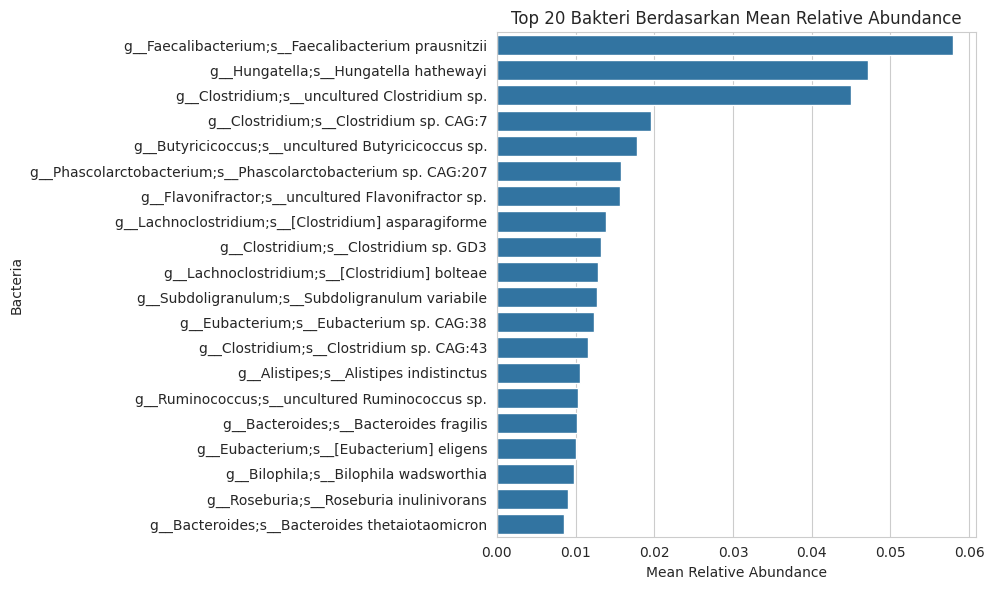

In [ ]:
# STEP 1.26 — Top 20 bakteri berdasarkan mean relative abundance
# Proses ini mencari bakteri dengan rata-rata kelimpahan relatif tertinggi pada seluruh sampel.

top_bacteria = X_relative.mean().sort_values(ascending=False).head(20)

top_bacteria_df = top_bacteria.reset_index()
top_bacteria_df.columns = ["Bacteria", "Mean_Relative_Abundance"]

display(top_bacteria_df)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_bacteria_df,
    x="Mean_Relative_Abundance",
    y="Bacteria"
)
plt.title("Top 20 Bakteri Berdasarkan Mean Relative Abundance")
plt.xlabel("Mean Relative Abundance")
plt.ylabel("Bacteria")
plt.tight_layout()
plt.show()

,Bacteria,Prevalence
0,g__Veillonella;s__Veillonella seminalis,1.0
1,g__Veillonella;s__Veillonella parvula,1.0
2,g__Unclassified;s__uncultured bacterium,1.0
3,g__Unclassified;s__butyrate-producing bacterium SS3_4,1.0
4,g__Unclassified;s__bacterium MS4,1.0
5,g__Unclassified;s__bacterium LF-3,1.0
6,g__Unclassified;s__bacterium F083,1.0
7,g__Unclassified;s__[Eubacterium] rectale,1.0
8,g__Unclassified;s__[Eubacterium] dolichum,1.0
9,g__Unclassified;s__[Bacteroides] pectinophilus,1.0


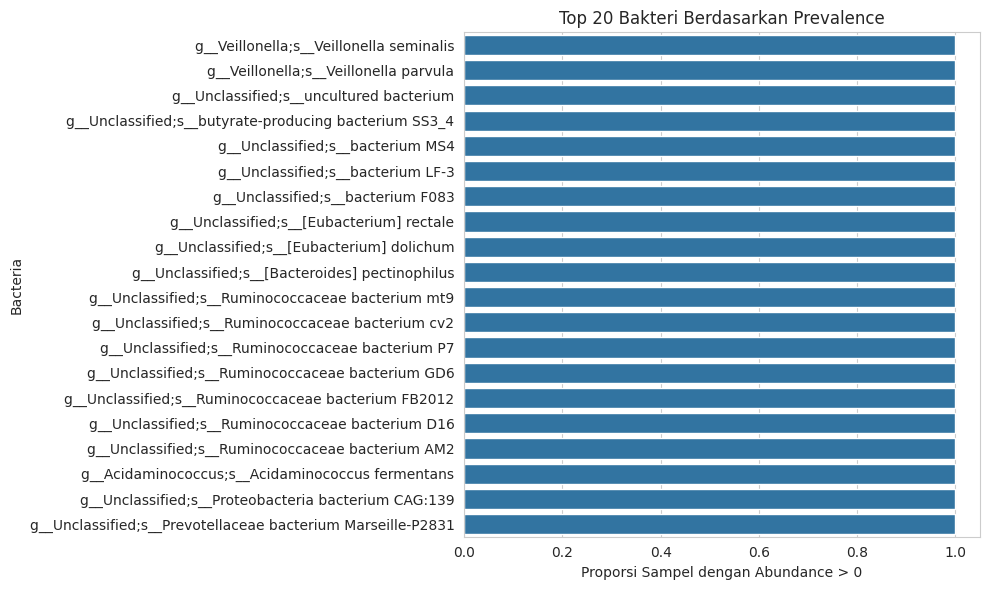

In [ ]:
# STEP 1.27 — Top 20 bakteri berdasarkan prevalence
# Proses ini mencari bakteri yang paling sering muncul pada sampel.

prevalence = (X_counts_for_eda > 0).mean().sort_values(ascending=False).head(20)

prevalence_df = prevalence.reset_index()
prevalence_df.columns = ["Bacteria", "Prevalence"]

display(prevalence_df)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=prevalence_df,
    x="Prevalence",
    y="Bacteria"
)
plt.title("Top 20 Bakteri Berdasarkan Prevalence")
plt.xlabel("Proporsi Sampel dengan Abundance > 0")
plt.ylabel("Bacteria")
plt.tight_layout()
plt.show()

,Bacteria,Prevalence
0,g__Clostridium;s__Clostridium clostridioforme CAG:511,0.983333
1,g__Clostridium;s__Clostridium intestinale,0.983333
2,g__Unclassified;s__unidentified phage,0.983333
3,g__Veillonella;s__Veillonella sp. CAG:933,0.983333
4,g__Youngiibacter;s__Youngiibacter fragilis,0.983333
5,g__Oribacterium;s__Oribacterium sp. NK2B42,0.983333
6,g__Oribacterium;s__Oribacterium sp. P6A1,0.983333
7,g__Oscillibacter;s__Oscillibacter sp. KLE 1728,0.983333
8,g__Unclassified;s__Firmicutes bacterium CAG:114,0.983333
9,g__Unclassified;s__Firmicutes bacterium CAG:145,0.983333


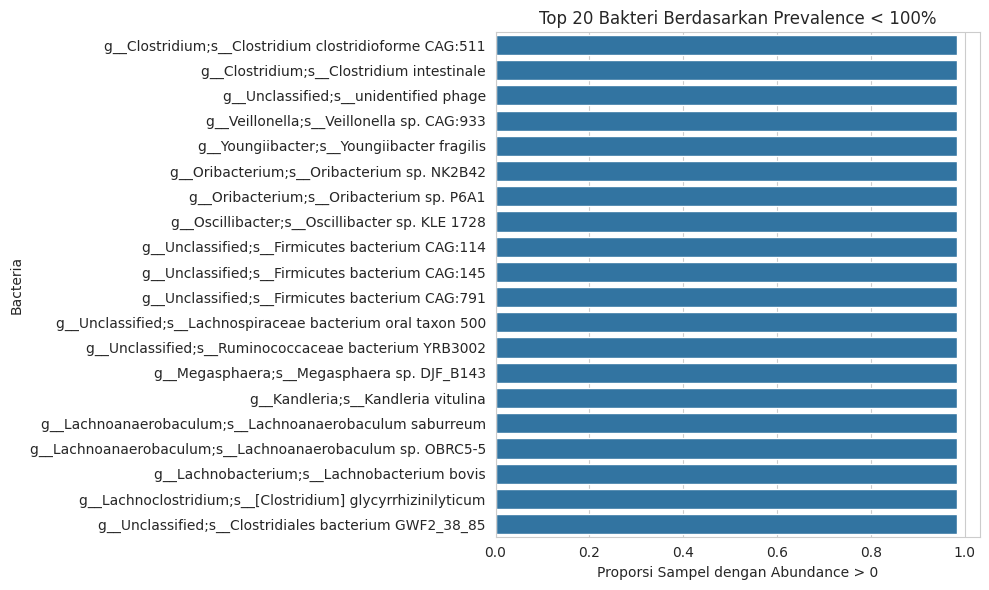

In [ ]:
# STEP 1.27b — Top 20 bakteri berdasarkan prevalence < 100%
# Proses ini menampilkan bakteri yang sering muncul, tetapi mengecualikan bakteri yang muncul di semua sampel.

prevalence_all = (X_counts_for_eda > 0).mean().sort_values(ascending=False)

prevalence_filtered = prevalence_all[prevalence_all < 1.0].head(20)

prevalence_filtered_df = prevalence_filtered.reset_index()
prevalence_filtered_df.columns = ["Bacteria", "Prevalence"]

display(prevalence_filtered_df)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=prevalence_filtered_df,
    x="Prevalence",
    y="Bacteria"
)
plt.title("Top 20 Bakteri Berdasarkan Prevalence < 100%")
plt.xlabel("Proporsi Sampel dengan Abundance > 0")
plt.ylabel("Bacteria")
plt.tight_layout()
plt.show()

,Label,Count
0,Control,30
1,ASD,30


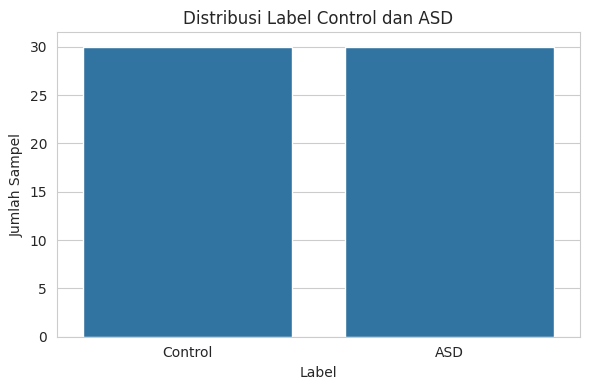

In [ ]:
# STEP 1.28 — Visualisasi distribusi label
# Proses ini menampilkan keseimbangan jumlah sampel Control dan ASD.

label_distribution = df_labeled["Label"].value_counts().reset_index()
label_distribution.columns = ["Label", "Count"]

display(label_distribution)

plt.figure(figsize=(6, 4))
sns.barplot(
    data=label_distribution,
    x="Label",
    y="Count"
)
plt.title("Distribusi Label Control dan ASD")
plt.xlabel("Label")
plt.ylabel("Jumlah Sampel")
plt.tight_layout()
plt.show()

,Sample_ID,Label,Total_Abundance
0,A3,Control,73596
1,A5,Control,86591
2,A6,Control,58149
3,A9,Control,117425
4,A31,Control,95710


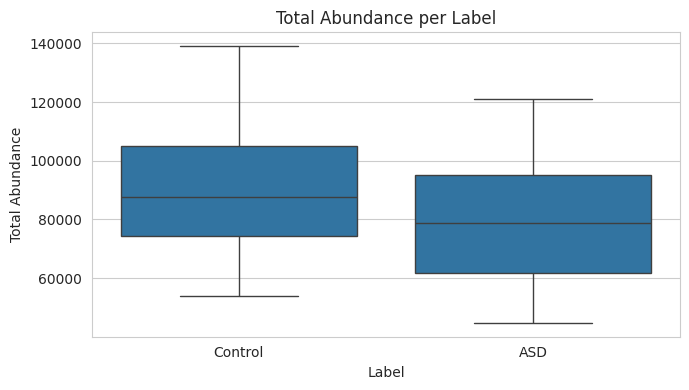

In [ ]:
# STEP 1.29 — Total abundance berdasarkan label
# Proses ini membandingkan total abundance antar kelompok hanya untuk eksplorasi, bukan untuk modeling.

df_eda_labeled = df_labeled[["Sample_ID", "Label"]].copy()
df_eda_labeled["Total_Abundance"] = X_counts_for_eda.sum(axis=1)

display(df_eda_labeled.head())

plt.figure(figsize=(7, 4))
sns.boxplot(
    data=df_eda_labeled,
    x="Label",
    y="Total_Abundance"
)
plt.title("Total Abundance per Label")
plt.xlabel("Label")
plt.ylabel("Total Abundance")
plt.tight_layout()
plt.show()

Label,Bacteria,ASD,Control,Absolute_Difference
0,g__Hungatella;s__Hungatella hathewayi,0.052174,0.042227,0.009946
1,g__Clostridium;s__uncultured Clostridium sp.,0.048826,0.041055,0.007772
2,g__Phascolarctobacterium;s__Phascolarctobacterium sp. CAG:207,0.012316,0.019180,0.006864
3,g__Butyricicoccus;s__uncultured Butyricicoccus sp.,0.020286,0.015316,0.004970
4,g__Faecalibacterium;s__Faecalibacterium prausnitzii,0.060009,0.056028,0.003982
5,g__Bacteroides;s__Bacteroides stercoris,0.003176,0.006836,0.003659
6,g__Eubacterium;s__Eubacterium sp. CAG:156,0.005871,0.002373,0.003498
7,g__Clostridium;s__Clostridium sp. CAG:299,0.004187,0.007666,0.003479
8,g__Prevotella;s__Prevotella sp. CAG:279,0.000083,0.003523,0.003440
9,g__Lachnoclostridium;s__[Clostridium] asparagiforme,0.015418,0.012344,0.003075


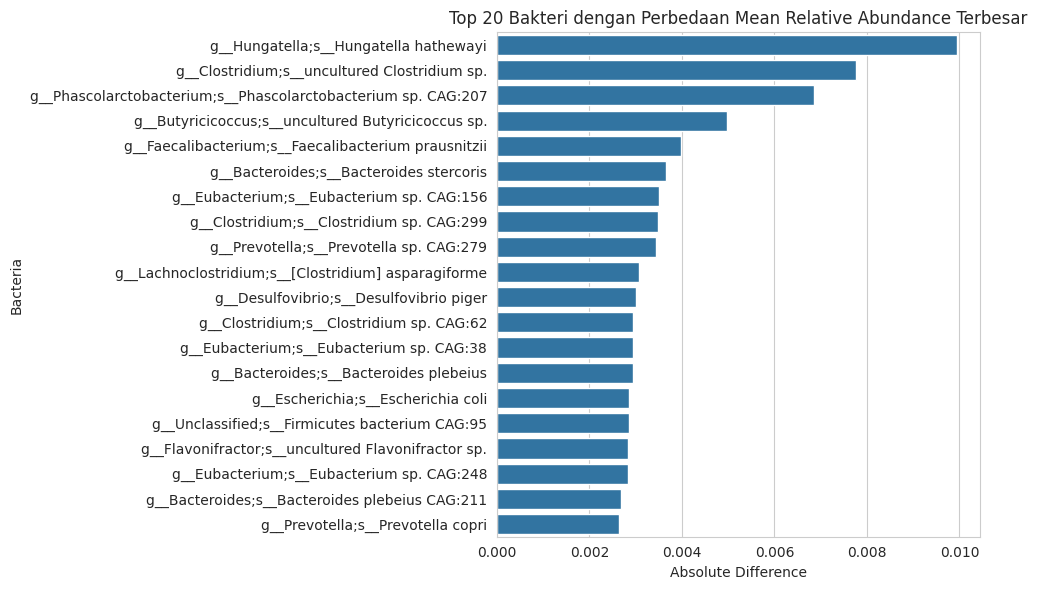

In [ ]:
# STEP 1.30 — Perbedaan deskriptif abundance antar label
# Proses ini mencari bakteri dengan perbedaan rata-rata relative abundance terbesar antara Control dan ASD.

relative_with_label = X_relative.copy()
relative_with_label["Label"] = df_labeled["Label"].values

group_mean = relative_with_label.groupby("Label").mean().T

group_mean["Absolute_Difference"] = (
    group_mean["ASD"] - group_mean["Control"]
).abs()

top_diff_bacteria = (
    group_mean
    .sort_values("Absolute_Difference", ascending=False)
    .head(20)
    .reset_index()
    .rename(columns={"index": "Bacteria"})
)

display(top_diff_bacteria)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_diff_bacteria,
    x="Absolute_Difference",
    y="Bacteria"
)
plt.title("Top 20 Bakteri dengan Perbedaan Mean Relative Abundance Terbesar")
plt.xlabel("Absolute Difference")
plt.ylabel("Bacteria")
plt.tight_layout()
plt.show()

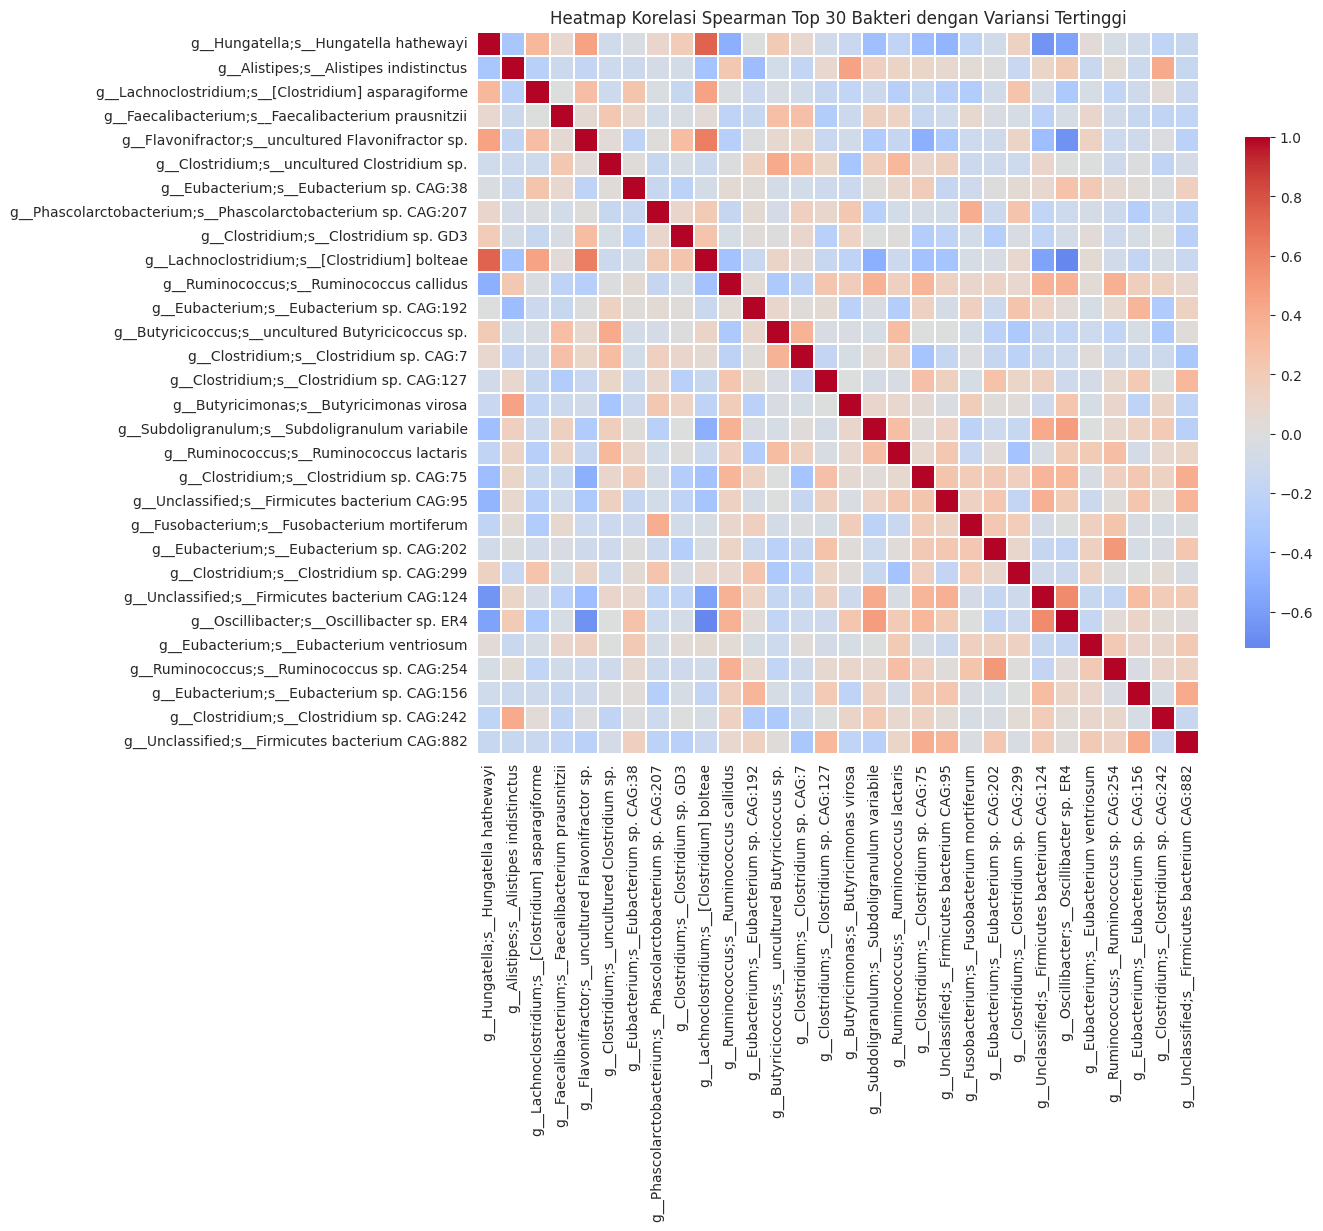

In [ ]:
# STEP 1.31 — Heatmap korelasi
# Proses ini menampilkan korelasi Spearman dari 30 bakteri dengan variansi tertinggi agar visualisasi tetap terbaca.

top_variable_features = X_relative.var().sort_values(ascending=False).head(30).index

corr_matrix = X_relative[top_variable_features].corr(method="spearman")

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.3,
    cbar_kws={"shrink": 0.7}
)
plt.title("Heatmap Korelasi Spearman Top 30 Bakteri dengan Variansi Tertinggi")
plt.tight_layout()
plt.show()

In [ ]:
# STEP 1.32 — Ringkasan akhir Step 1
# Proses ini merangkum kondisi akhir dataset sebelum masuk ke preprocessing dan modeling.

summary_step_1 = pd.DataFrame({
    "Item": [
        "Jumlah sampel",
        "Jumlah fitur bakteri",
        "Jumlah kelas",
        "Jumlah sampel Control",
        "Jumlah sampel ASD",
        "Missing value total",
        "Duplicate Sample_ID",
        "Persentase nilai nol",
        "Rasio fitur terhadap sampel"
    ],
    "Value": [
        df_labeled.shape[0],
        len(final_feature_cols),
        df_labeled["Label"].nunique(),
        (df_labeled["Label"] == "Control").sum(),
        (df_labeled["Label"] == "ASD").sum(),
        df_labeled.isnull().sum().sum(),
        df_labeled["Sample_ID"].duplicated().sum(),
        round(zero_percentage, 2),
        round(len(final_feature_cols) / df_labeled.shape[0], 2)
    ]
})

display(summary_step_1)

,Item,Value
0,Jumlah sampel,60.00
1,Jumlah fitur bakteri,5619.00
2,Jumlah kelas,2.00
3,Jumlah sampel Control,30.00
4,Jumlah sampel ASD,30.00
5,Missing value total,0.00
6,Duplicate Sample_ID,0.00
7,Persentase nilai nol,66.37
8,Rasio fitur terhadap sampel,93.65


In [ ]:
# STEP 1.33 — Simpan hasil Step 1
# Proses ini menyimpan dataset hasil transpose, dataset berlabel, dan tabel EDA ke Google Drive.

output_dir = "/content/drive/MyDrive/MAGANG/artikel/analisis perilaku anak autis/output_ml_asd"

os.makedirs(output_dir, exist_ok=True)

df_transposed.to_csv(f"{output_dir}/01_microbiome_transposed_without_label.csv", index=False)
df_labeled.to_csv(f"{output_dir}/02_microbiome_transposed_labeled.csv", index=False)
top_bacteria_df.to_csv(f"{output_dir}/03_top20_mean_relative_abundance.csv", index=False)
prevalence_df.to_csv(f"{output_dir}/04_top20_prevalence.csv", index=False)
top_diff_bacteria.to_csv(f"{output_dir}/05_top20_difference_control_vs_asd.csv", index=False)
summary_step_1.to_csv(f"{output_dir}/06_summary_step_1.csv", index=False)

print("Semua file Step 1 berhasil disimpan di:")
print(output_dir)

Semua file Step 1 berhasil disimpan di:
/content/drive/MyDrive/MAGANG/artikel/analisis perilaku anak autis/output_ml_asd


#PREPOCESSING

In [ ]:
# STEP 2.1 — Import library
# Proses ini menyiapkan library untuk split data, preprocessing, dan cross validation.

import os
import joblib
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, StratifiedKFold

RANDOM_STATE = 42

print("Library Step 2 siap digunakan.")

Library Step 2 siap digunakan.


In [ ]:
# STEP 2.2 — Load dataset berlabel
# Proses ini memastikan dataset hasil Step 1 tersedia untuk preprocessing dan split data.

output_dir = "/content/drive/MyDrive/MAGANG/artikel/analisis perilaku anak autis/output_ml_asd"
labeled_path = f"{output_dir}/02_microbiome_transposed_labeled.csv"

if "df_labeled" not in globals():
    df_labeled = pd.read_csv(labeled_path)
    print("df_labeled dibaca ulang dari Google Drive.")
else:
    print("df_labeled sudah tersedia dari Step 1.")

print("Shape df_labeled:", df_labeled.shape)
display(df_labeled.head())

df_labeled sudah tersedia dari Step 1.
Shape df_labeled: (60, 5622)


,Sample_ID,g__Absidia;s__Absidia glauca,g__Acaryochloris;s__Acaryochloris sp. CCMEE 5410,g__Acetanaerobacterium;s__Acetanaerobacterium elongatum,g__Acetivibrio;s__Acetivibrio cellulolyticus,g__Acetivibrio;s__Acetivibrio ethanolgignens,g__Acetoanaerobium;s__Acetoanaerobium sticklandii,g__Acetobacter;s__Acetobacter malorum,g__Acetobacter;s__Acetobacter sp. CAG:267,g__Acetobacter;s__Acetobacter sp. CAG:977,g__Acetobacterium;s__Acetobacterium bakii,g__Acetobacterium;s__Acetobacterium dehalogenans,g__Acetobacterium;s__Acetobacterium wieringae,g__Acetobacterium;s__Acetobacterium woodii,g__Acetohalobium;s__Acetohalobium arabaticum,g__Acetomicrobium;s__Acetomicrobium hydrogeniformans,g__Acetomicrobium;s__Acetomicrobium mobile,g__Acetonema;s__Acetonema longum,g__Acholeplasma;s__Acholeplasma axanthum,g__Acholeplasma;s__Acholeplasma brassicae,g__Acholeplasma;s__Acholeplasma equifetale,g__Acholeplasma;s__Acholeplasma granularum,g__Acholeplasma;s__Acholeplasma hippikon,g__Acholeplasma;s__Acholeplasma laidlawii,g__Acholeplasma;s__Acholeplasma modicum,g__Acholeplasma;s__Acholeplasma oculi,g__Acholeplasma;s__Acholeplasma palmae,g__Acholeplasma;s__Acholeplasma sp. CAG:878,g__Achromatium;s__Achromatium sp. WMS2,g__Achromatium;s__Candidatus Achromatium palustre,g__Achromobacter;s__Achromobacter piechaudii,g__Achromobacter;s__Achromobacter sp. 2789STDY5608607,g__Achromobacter;s__Achromobacter sp. 2789STDY5608609,g__Achromobacter;s__Achromobacter sp. ATCC35328,g__Achromobacter;s__Achromobacter xylosoxidans,g__Acidaminobacter;s__Acidaminobacter hydrogenoformans,g__Acidaminococcus;s__Acidaminococcus fermentans,g__Acidaminococcus;s__Acidaminococcus intestini,g__Acidaminococcus;s__Acidaminococcus intestini CAG:325,g__Acidaminococcus;s__Acidaminococcus sp. BV3L6,g__Acidaminococcus;s__Acidaminococcus sp. CAG:542,g__Acidaminococcus;s__Acidaminococcus sp. CAG:917,g__Acidaminococcus;s__Acidaminococcus sp. D21,g__Acidaminococcus;s__Acidaminococcus sp. HPA0509,g__Acidaminococcus;s__Acidaminococcus sp. Marseille-P2764,g__Acidibacillus;s__Acidibacillus ferrooxidans,g__Acidiferrobacter;s__Acidiferrobacter thiooxydans,g__Acidihalobacter;s__Acidihalobacter prosperus,g__Acidiphilium;s__Acidiphilium angustum,g__Acidiphilium;s__Acidiphilium sp. CAG:727,g__Acidiplasma;s__Acidiplasma cupricumulans,g__Acidipropionibacterium;s__Acidipropionibacterium acidipropionici,g__Acidithiobacillus;s__Acidithiobacillus caldus,g__Acidithiobacillus;s__Acidithiobacillus ferrivorans,g__Acidithiobacillus;s__Acidithiobacillus thiooxidans,g__Acidithrix;s__Acidithrix ferrooxidans,g__Acidobacterium;s__Acidobacterium ailaaui,g__Acidobacterium;s__Acidobacterium capsulatum,g__Acidocella;s__Acidocella aminolytica,g__Acidovorax;s__Acidovorax citrulli,...,g__Vibrio;s__Vibrio sp. MEBiC08052,g__Vibrio;s__Vibrio sp. OY15,g__Vibrio;s__Vibrio splendidus,g__Vibrio;s__Vibrio tasmaniensis,g__Vibrio;s__Vibrio tritonius,g__Vibrio;s__Vibrio variabilis,g__Vibrio;s__Vibrio vulnificus,g__Vibrio;s__Vibrio xiamenensis,g__Vibrio;s__uncultured Vibrio sp.,g__Virgibacillus;s__Virgibacillus alimentarius,g__Virgibacillus;s__Virgibacillus pantothenticus,g__Virgibacillus;s__Virgibacillus salinus,g__Virgibacillus;s__Virgibacillus soli,g__Virgibacillus;s__Virgibacillus sp. SK-1,g__Virgibacillus;s__Virgibacillus sp. Vm-5,g__Vitellibacter;s__Vitellibacter soesokkakensis,g__Vitellibacter;s__Vitellibacter vladivostokensis,g__Vulcanibacillus;s__Vulcanibacillus modesticaldus,g__Vulgatibacter;s__Vulgatibacter incomptus,g__Waddlia;s__Waddlia chondrophila,g__Weeksella;s__Weeksella sp. FF8,g__Weeksella;s__Weeksella sp. HMSC059D05,g__Weeksella;s__Weeksella virosa,g__Weissella;s__Weissella bombi,g__Weissella;s__Weissella cibaria,g__Wenyingzhuangia;s__Wenyingzhuangia fucanilytica,g__Wenzhouxiangella;s__Wenzhouxiangella marina,g__Williamsia;s__Williamsia sp. D3,g__Winogradskyella;s__Winogradskyella psychrotolerans,g__Winogradskyella;s__Winogradskyella sp. PG-2,g__Winogradskyella;s__Winogradskyella sp. RHA_55,g__Winogradskyella;s__Winog

In [ ]:
# STEP 2.3 — Memisahkan fitur dan target
# Proses ini memisahkan kolom bakteri sebagai X dan Target sebagai y.

non_feature_cols = [
    "Sample_ID",
    "Label",
    "Target",
    "Total_Abundance",
    "Sample_Group_Code"
]

feature_cols = [
    col for col in df_labeled.columns
    if col not in non_feature_cols
]

X = df_labeled[feature_cols].copy()
y = df_labeled["Target"].copy()
sample_ids = df_labeled["Sample_ID"].copy()

print("Shape X:", X.shape)
print("Shape y:", y.shape)

print("\nDistribusi target:")
display(y.value_counts().sort_index())

Shape X: (60, 5619)
Shape y: (60,)

Distribusi target:


,count
Target,
0,30
1,30


In [ ]:
# STEP 2.4 — Validasi anti-leakage
# Proses ini memastikan Sample_ID, Label, dan Target tidak ikut menjadi fitur model.

print("Missing value pada X:", X.isnull().sum().sum())
print("Missing value pada y:", y.isnull().sum())

for col in ["Sample_ID", "Label", "Target"]:
    if col in X.columns:
        raise ValueError(f"Kolom leakage terdeteksi di X: {col}")

if set(y.unique()) != {0, 1}:
    raise ValueError("Target harus berisi 0 = Control dan 1 = ASD.")

print("Validasi awal aman: X hanya berisi fitur bakteri.")

Missing value pada X: 0
Missing value pada y: 0
Validasi awal aman: X hanya berisi fitur bakteri.


In [ ]:
# STEP 2.5 — Membuat preprocessor mikrobiom
# Proses ini membuat preprocessing yang fit hanya pada data train agar tidak terjadi data leakage.

class MicrobiomePreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, min_prevalence=0.10):
        self.min_prevalence = min_prevalence

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X).copy()
        self.feature_names_in_ = list(X_df.columns)

        X_df = X_df.apply(pd.to_numeric, errors="coerce").fillna(0)

        prevalence = (X_df > 0).mean(axis=0)
        selected = prevalence[prevalence >= self.min_prevalence].index.tolist()

        X_selected = X_df[selected]
        row_sums = X_selected.sum(axis=1).replace(0, np.nan)
        X_relative = X_selected.div(row_sums, axis=0).fillna(0)

        variance = X_relative.var(axis=0)
        self.selected_features_ = variance[variance > 0].index.tolist()

        if len(self.selected_features_) == 0:
            raise ValueError("Tidak ada fitur yang lolos preprocessing.")

        return self

    def transform(self, X):
        X_df = pd.DataFrame(X).copy()
        X_df = X_df[self.feature_names_in_]
        X_df = X_df.apply(pd.to_numeric, errors="coerce").fillna(0)

        X_selected = X_df[self.selected_features_]
        row_sums = X_selected.sum(axis=1).replace(0, np.nan)
        X_relative = X_selected.div(row_sums, axis=0).fillna(0)

        return X_relative

    def get_feature_names_out(self):
        return np.array(self.selected_features_)

print("MicrobiomePreprocessor siap digunakan.")

MicrobiomePreprocessor siap digunakan.


In [ ]:
# STEP 2.6 — Split data
# Proses ini membagi data menjadi train dan test dengan proporsi kelas tetap seimbang.

split_configs = {
    "70:30": 0.30,
    "80:20": 0.20,
    "90:10": 0.10
}

splits = {}
summary_rows = []

for split_name, test_size in split_configs.items():

    X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
        X,
        y,
        sample_ids,
        test_size=test_size,
        random_state=RANDOM_STATE,
        stratify=y
    )

    preprocessor = MicrobiomePreprocessor(min_prevalence=0.10)

    X_train_prep = preprocessor.fit_transform(X_train)
    X_test_prep = preprocessor.transform(X_test)

    overlap = set(id_train).intersection(set(id_test))

    splits[split_name] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "id_train": id_train,
        "id_test": id_test,
        "preprocessor": preprocessor,
        "X_train_prep": X_train_prep,
        "X_test_prep": X_test_prep
    }

    summary_rows.append({
        "Split": split_name,
        "Train Samples": X_train.shape[0],
        "Test Samples": X_test.shape[0],
        "Control Train": int((y_train == 0).sum()),
        "ASD Train": int((y_train == 1).sum()),
        "Control Test": int((y_test == 0).sum()),
        "ASD Test": int((y_test == 1).sum()),
        "Original Features": X.shape[1],
        "Selected Features": X_train_prep.shape[1],
        "Overlap Sample_ID": len(overlap)
    })

split_summary_df = pd.DataFrame(summary_rows)

display(split_summary_df)

,Split,Train Samples,Test Samples,Control Train,ASD Train,Control Test,ASD Test,Original Features,Selected Features,Overlap Sample_ID
0,70:30,42,18,21,21,9,9,5619,3378,0
1,80:20,48,12,24,24,6,6,5619,3547,0
2,90:10,54,6,27,27,3,3,5619,3457,0


In [ ]:
# STEP 2.7 — Membuat 10-Fold Stratified Cross Validation
# Proses ini menyiapkan validasi silang 10 fold dengan proporsi Control dan ASD tetap seimbang.

cv_10fold = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=RANDOM_STATE
)

fold_rows = []

for fold, (train_idx, val_idx) in enumerate(cv_10fold.split(X, y), start=1):
    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]

    fold_rows.append({
        "Fold": fold,
        "Train Samples": len(train_idx),
        "Validation Samples": len(val_idx),
        "Control Validation": int((y_val_fold == 0).sum()),
        "ASD Validation": int((y_val_fold == 1).sum())
    })

fold_summary_df = pd.DataFrame(fold_rows)

display(fold_summary_df)

,Fold,Train Samples,Validation Samples,Control Validation,ASD Validation
0,1,54,6,3,3
1,2,54,6,3,3
2,3,54,6,3,3
3,4,54,6,3,3
4,5,54,6,3,3
5,6,54,6,3,3
6,7,54,6,3,3
7,8,54,6,3,3
8,9,54,6,3,3
9,10,54,6,3,3


In [ ]:
# STEP 2.8 — Simpan hasil Step 2
# Proses ini menyimpan ringkasan split, ringkasan cross validation, dan objek split ke Google Drive.

os.makedirs(output_dir, exist_ok=True)

split_summary_df.to_csv(f"{output_dir}/07_split_summary.csv", index=False)
fold_summary_df.to_csv(f"{output_dir}/08_10fold_summary.csv", index=False)

joblib.dump(splits, f"{output_dir}/step2_splits.joblib")
joblib.dump(cv_10fold, f"{output_dir}/step2_cv_10fold.joblib")

print("Output Step 2 berhasil disimpan di:")
print(output_dir)

Output Step 2 berhasil disimpan di:
/content/drive/MyDrive/MAGANG/artikel/analisis perilaku anak autis/output_ml_asd


# MODELING DECISION TREE & RANDOM FOREST

In [ ]:
# STEP 3.1 — Import library modeling
# Proses ini menyiapkan model, pipeline, grid search, evaluasi, dan visualisasi performa.

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, cross_validate

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

RANDOM_STATE = 42

print("Library Step 3 siap digunakan.")

Library Step 3 siap digunakan.


In [ ]:
# STEP 3.2 — Fungsi evaluasi model
# Proses ini membuat fungsi ringkas untuk menghitung accuracy, precision, recall, F1-score, ROC-AUC, dan confusion matrix.

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, split_name):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    y_test_proba = model.predict_proba(X_test)[:, 1]

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    result = {
        "Model": model_name,
        "Split": split_name,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Accuracy": test_accuracy,
        "Precision": precision_score(y_test, y_test_pred, zero_division=0),
        "Recall": recall_score(y_test, y_test_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_test_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_test_proba),
        "Overfitting Gap": train_accuracy - test_accuracy
    }

    cm = confusion_matrix(y_test, y_test_pred)

    return result, cm, y_test_pred, y_test_proba, model

In [ ]:
# STEP 3.3 — Baseline Decision Tree dan Random Forest
# Proses ini melatih Decision Tree dan Random Forest pada data train yang sudah dipreprocess secara anti-leakage.

baseline_results = []
confusion_matrices = {}
trained_baseline_models = {}

for split_name, data in splits.items():

    X_train_prep = data["X_train_prep"]
    X_test_prep = data["X_test_prep"]
    y_train = data["y_train"]
    y_test = data["y_test"]

    models = {
        "Decision Tree": DecisionTreeClassifier(
            random_state=RANDOM_STATE,
            max_depth=5,
            min_samples_leaf=2
        ),
        "Random Forest": RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            class_weight="balanced",
            n_jobs=-1
        )
    }

    for model_name, model in models.items():
        result, cm, y_pred, y_proba, trained_model = evaluate_model(
            model=model,
            X_train=X_train_prep,
            X_test=X_test_prep,
            y_train=y_train,
            y_test=y_test,
            model_name=model_name,
            split_name=split_name
        )

        baseline_results.append(result)
        confusion_matrices[(model_name, split_name)] = cm
        trained_baseline_models[(model_name, split_name)] = trained_model

baseline_results_df = pd.DataFrame(baseline_results)

display(baseline_results_df)

,Model,Split,Train Accuracy,Test Accuracy,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Overfitting Gap
0,Decision Tree,70:30,1.000000,0.611111,0.611111,0.625000,0.555556,0.588235,0.611111,0.388889
1,Random Forest,70:30,1.000000,0.833333,0.833333,0.750000,1.000000,0.857143,0.913580,0.166667
2,Decision Tree,80:20,0.979167,0.833333,0.833333,0.833333,0.833333,0.833333,0.833333,0.145833
3,Random Forest,80:20,1.000000,0.916667,0.916667,0.857143,1.000000,0.923077,0.944444,0.083333
4,Decision Tree,90:10,0.981481,0.833333,0.833333,0.750000,1.000000,0.857143,0.833333,0.148148
5,Random Forest,90:10,1.000000,0.833333,0.833333,0.750000,1.000000,0.857143,0.888889,0.166667


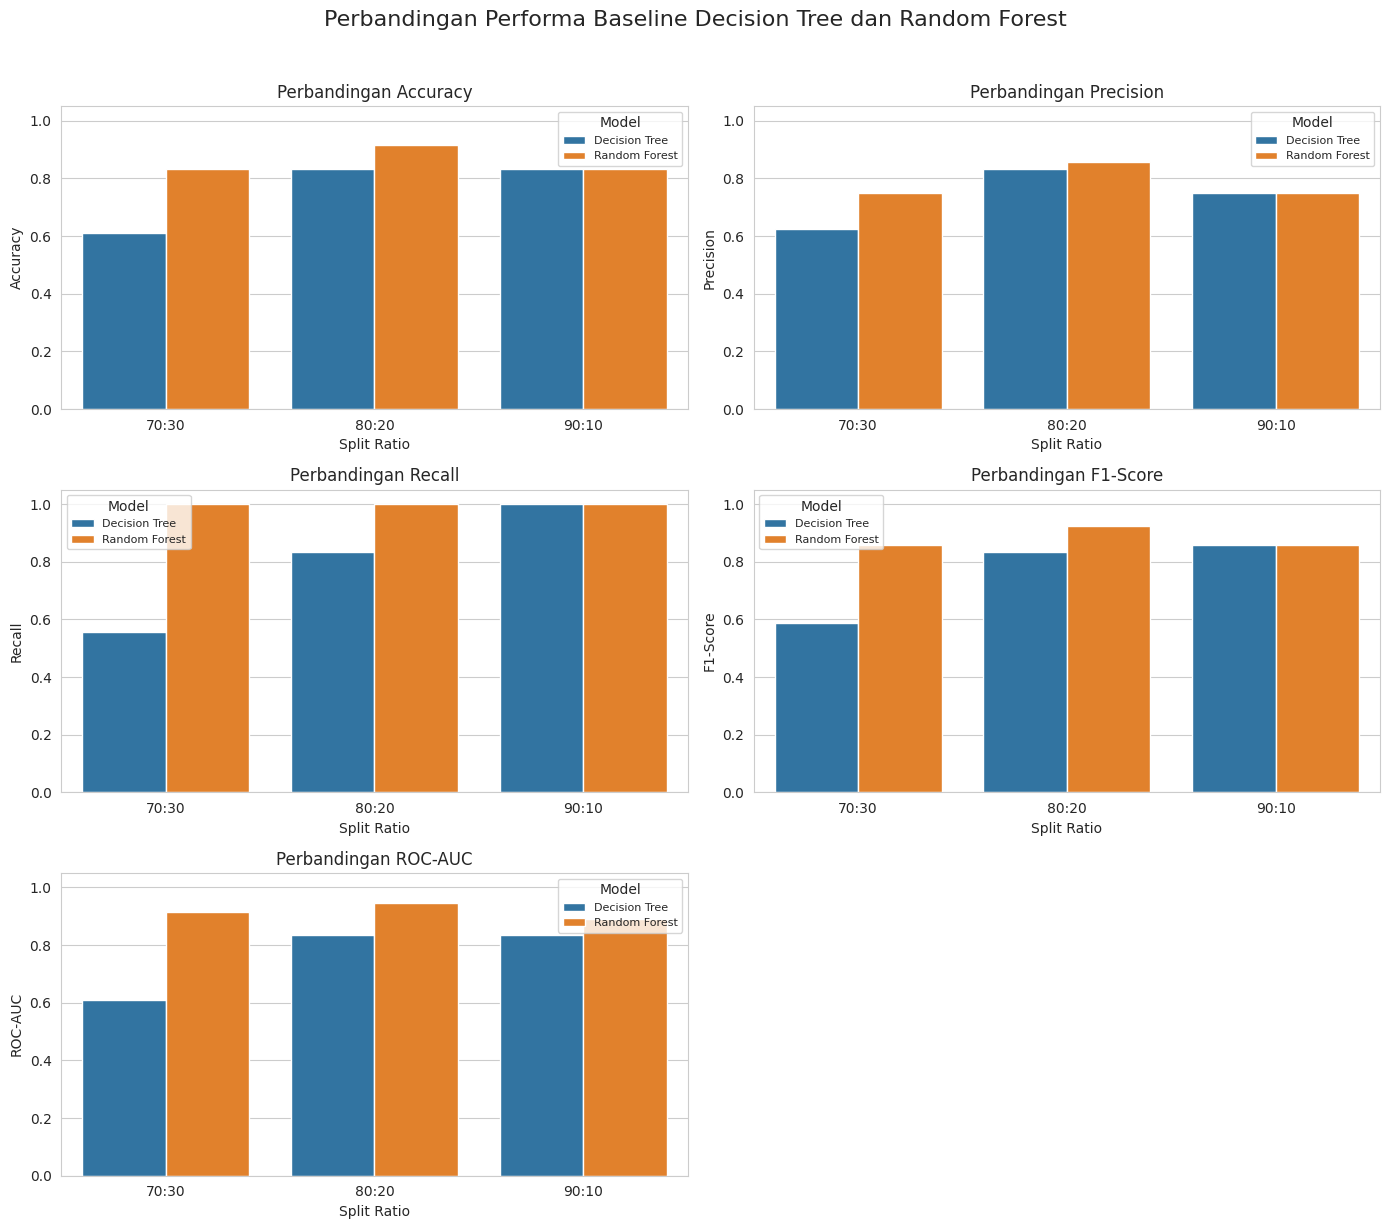

In [ ]:
# STEP 3.4 — Visualisasi performa baseline dalam 2 kolom
# Proses ini membandingkan performa Decision Tree dan Random Forest dengan layout grafik yang lebih ringkas.

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

n_cols = 2
n_rows = int(np.ceil(len(metrics_to_plot) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 12))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    sns.barplot(
        data=baseline_results_df,
        x="Split",
        y=metric,
        hue="Model",
        ax=axes[i]
    )
    axes[i].set_title(f"Perbandingan {metric}")
    axes[i].set_xlabel("Split Ratio")
    axes[i].set_ylabel(metric)
    axes[i].set_ylim(0, 1.05)
    axes[i].legend(title="Model", fontsize=8)

# Menghapus subplot kosong jika jumlah grafik ganjil
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Perbandingan Performa Baseline Decision Tree dan Random Forest", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

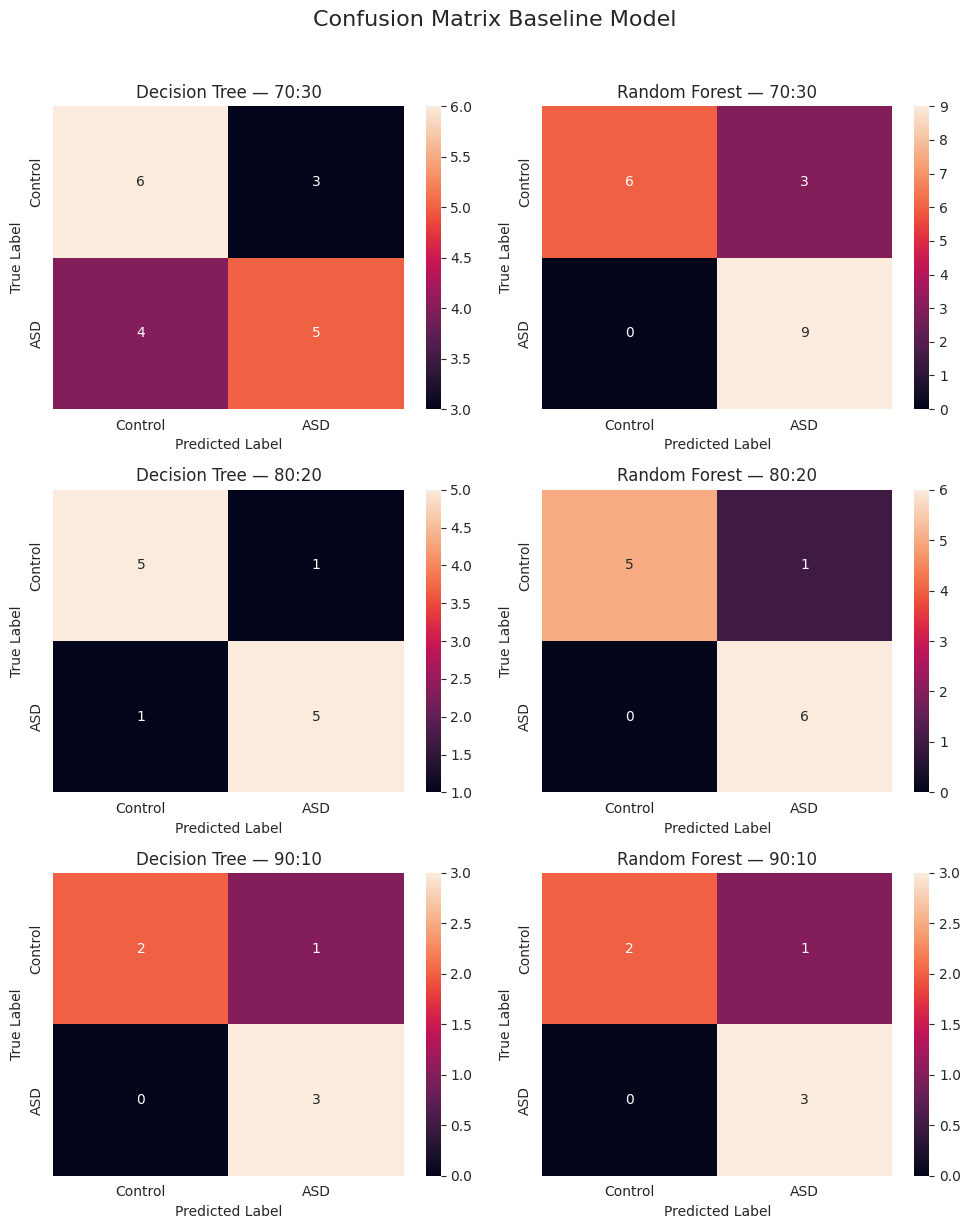

In [ ]:
# STEP 3.5 — Confusion matrix baseline dalam 2 kolom
# Proses ini menampilkan confusion matrix setiap model dan split dengan layout yang lebih ringkas.

cm_items = list(confusion_matrices.items())

# Urutan tampilan dibuat lebih rapi
model_order = {
    "Decision Tree": 0,
    "Random Forest": 1
}

split_order = {
    "70:30": 0,
    "80:20": 1,
    "90:10": 2
}

cm_items = sorted(
    cm_items,
    key=lambda x: (
        split_order.get(x[0][1], 99),
        model_order.get(x[0][0], 99)
    )
)

n_cols = 2
n_rows = int(np.ceil(len(cm_items) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4 * n_rows))
axes = axes.flatten()

for i, ((model_name, split_name), cm) in enumerate(cm_items):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=["Control", "ASD"],
        yticklabels=["Control", "ASD"],
        ax=axes[i]
    )
    axes[i].set_title(f"{model_name} — {split_name}")
    axes[i].set_xlabel("Predicted Label")
    axes[i].set_ylabel("True Label")

# Menghapus subplot kosong jika ada
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Confusion Matrix Baseline Model", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# STEP 3.6 — GridSearchCV Random Forest versi ringan
# Proses ini mencari parameter Random Forest terbaik dengan grid yang lebih kecil agar runtime lebih realistis.

rf_pipeline = Pipeline([
    ("preprocess", MicrobiomePreprocessor()),
    ("model", RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_param_grid = {
    "preprocess__min_prevalence": [0.10],
    "model__n_estimators": [200],
    "model__max_depth": [None, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt"]
}

gridsearch_results = []
best_rf_models = {}

for split_name, data in splits.items():

    print("\n" + "="*80)
    print(f"GridSearchCV Random Forest — Split {split_name}")
    print("="*80)

    grid_search = GridSearchCV(
        estimator=rf_pipeline,
        param_grid=rf_param_grid,
        scoring="roc_auc",
        cv=cv_10fold,
        n_jobs=-1,
        refit=True,
        return_train_score=True,
        verbose=1
    )

    grid_search.fit(data["X_train"], data["y_train"])

    best_model = grid_search.best_estimator_

    y_train_pred = best_model.predict(data["X_train"])
    y_test_pred = best_model.predict(data["X_test"])

    y_test_proba = best_model.predict_proba(data["X_test"])[:, 1]

    train_accuracy = accuracy_score(data["y_train"], y_train_pred)
    test_accuracy = accuracy_score(data["y_test"], y_test_pred)

    result = {
        "Model": "Random Forest GridSearchCV",
        "Split": split_name,
        "Best CV ROC-AUC": grid_search.best_score_,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Accuracy": test_accuracy,
        "Precision": precision_score(data["y_test"], y_test_pred, zero_division=0),
        "Recall": recall_score(data["y_test"], y_test_pred, zero_division=0),
        "F1-Score": f1_score(data["y_test"], y_test_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(data["y_test"], y_test_proba),
        "Overfitting Gap": train_accuracy - test_accuracy,
        "Best Params": grid_search.best_params_
    }

    gridsearch_results.append(result)
    best_rf_models[split_name] = best_model

gridsearch_results_df = pd.DataFrame(gridsearch_results)

display(gridsearch_results_df)


GridSearchCV Random Forest — Split 70:30
Fitting 10 folds for each of 4 candidates, totalling 40 fits

GridSearchCV Random Forest — Split 80:20
Fitting 10 folds for each of 4 candidates, totalling 40 fits

GridSearchCV Random Forest — Split 90:10
Fitting 10 folds for each of 4 candidates, totalling 40 fits


,Model,Split,Best CV ROC-AUC,Train Accuracy,Test Accuracy,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Overfitting Gap,Best Params
0,Random Forest GridSearchCV,70:30,0.850000,1.0,0.888889,0.888889,0.818182,1.0,0.900000,0.901235,0.111111,"{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 200, 'preprocess__min_prevalence': ..."
1,Random Forest GridSearchCV,80:20,0.983333,1.0,0.916667,0.916667,0.857143,1.0,0.923077,0.944444,0.083333,"{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__n_estimators': 200, 'preprocess__min_prevalence': ..."
2,Random Forest GridSearchCV,90:10,0.927778,1.0,0.833333,0.833333,0.750000,1.0,0.857143,0.888889,0.166667,"{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 200, 'preprocess__min_prevalence': ..."


In [ ]:
# STEP 3.7 — 10-Fold Cross Validation
# Proses ini mengevaluasi model menggunakan 10-fold stratified CV pada seluruh data dengan preprocessing di dalam pipeline.

cv_models = {
    "Decision Tree CV": Pipeline([
        ("preprocess", MicrobiomePreprocessor(min_prevalence=0.10)),
        ("model", DecisionTreeClassifier(
            random_state=RANDOM_STATE,
            max_depth=5,
            min_samples_leaf=2
        ))
    ]),
    "Random Forest CV": Pipeline([
        ("preprocess", MicrobiomePreprocessor(min_prevalence=0.10)),
        ("model", RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_estimators=300,
            min_samples_leaf=2,
            class_weight="balanced",
            n_jobs=-1
        ))
    ])
}

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = []

for model_name, model in cv_models.items():

    scores = cross_validate(
        estimator=model,
        X=X,
        y=y,
        cv=cv_10fold,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,
        "CV Accuracy Mean": scores["test_accuracy"].mean(),
        "CV Accuracy Std": scores["test_accuracy"].std(),
        "CV Precision Mean": scores["test_precision"].mean(),
        "CV Recall Mean": scores["test_recall"].mean(),
        "CV F1 Mean": scores["test_f1"].mean(),
        "CV ROC-AUC Mean": scores["test_roc_auc"].mean(),
        "CV ROC-AUC Std": scores["test_roc_auc"].std(),
        "Train Accuracy Mean": scores["train_accuracy"].mean(),
        "Overfitting Gap CV": scores["train_accuracy"].mean() - scores["test_accuracy"].mean()
    })

cv_results_df = pd.DataFrame(cv_results)

display(cv_results_df)

,Model,CV Accuracy Mean,CV Accuracy Std,CV Precision Mean,CV Recall Mean,CV F1 Mean,CV ROC-AUC Mean,CV ROC-AUC Std,Train Accuracy Mean,Overfitting Gap CV
0,Decision Tree CV,0.900000,0.110554,0.925000,0.9,0.887143,0.900000,0.110554,0.985185,0.085185
1,Random Forest CV,0.833333,0.149071,0.816667,0.9,0.846667,0.933333,0.073703,1.000000,0.166667


In [ ]:
# STEP 3.8 — Memilih model terbaik
# Proses ini memilih model terbaik berdasarkan ROC-AUC dan F1-score, bukan accuracy saja.

all_results_df = pd.concat([
    baseline_results_df,
    gridsearch_results_df.drop(columns=["Best Params"], errors="ignore")
], ignore_index=True)

all_results_df = all_results_df.sort_values(
    by=["ROC-AUC", "F1-Score", "Accuracy"],
    ascending=False
)

display(all_results_df)

best_result = all_results_df.iloc[0]

print("Model terbaik berdasarkan ROC-AUC, F1-score, dan Accuracy:")
display(best_result)

,Model,Split,Train Accuracy,Test Accuracy,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Overfitting Gap,Best CV ROC-AUC
3,Random Forest,80:20,1.000000,0.916667,0.916667,0.857143,1.000000,0.923077,0.944444,0.083333,NaN
7,Random Forest GridSearchCV,80:20,1.000000,0.916667,0.916667,0.857143,1.000000,0.923077,0.944444,0.083333,0.983333
1,Random Forest,70:30,1.000000,0.833333,0.833333,0.750000,1.000000,0.857143,0.913580,0.166667,NaN
6,Random Forest GridSearchCV,70:30,1.000000,0.888889,0.888889,0.818182,1.000000,0.900000,0.901235,0.111111,0.850000
5,Random Forest,90:10,1.000000,0.833333,0.833333,0.750000,1.000000,0.857143,0.888889,0.166667,NaN
8,Random Forest GridSearchCV,90:10,1.000000,0.833333,0.833333,0.750000,1.000000,0.857143,0.888889,0.166667,0.927778
4,Decision Tree,90:10,0.981481,0.833333,0.833333,0.750000,1.000000,0.857143,0.833333,0.148148,NaN
2,Decision Tree,80:20,0.979167,0.833333,0.833333,0.833333,0.833333,0.833333,0.833333,0.145833,NaN
0,Decision Tree,70:30,1.000000,0.611111,0.611111,0.625000,0.555556,0.588235,0.611111,0.388889,NaN


Model terbaik berdasarkan ROC-AUC, F1-score, dan Accuracy:


,3
Model,Random Forest
Split,80:20
Train Accuracy,1.0
Test Accuracy,0.916667
Accuracy,0.916667
Precision,0.857143
Recall,1.0
F1-Score,0.923077
ROC-AUC,0.944444
Overfitting Gap,0.083333


In [ ]:
# STEP 3.9 — Cek overfitting
# Proses ini menandai model yang memiliki gap besar antara akurasi train dan test.

overfitting_check_df = all_results_df[[
    "Model",
    "Split",
    "Train Accuracy",
    "Test Accuracy",
    "Overfitting Gap",
    "Accuracy",
    "F1-Score",
    "ROC-AUC"
]].copy()

def interpret_overfitting(gap):
    if gap >= 0.25:
        return "Overfitting tinggi"
    elif gap >= 0.10:
        return "Perlu diwaspadai"
    else:
        return "Relatif stabil"

overfitting_check_df["Interpretasi"] = overfitting_check_df["Overfitting Gap"].apply(interpret_overfitting)

display(overfitting_check_df)

,Model,Split,Train Accuracy,Test Accuracy,Overfitting Gap,Accuracy,F1-Score,ROC-AUC,Interpretasi
3,Random Forest,80:20,1.000000,0.916667,0.083333,0.916667,0.923077,0.944444,Relatif stabil
7,Random Forest GridSearchCV,80:20,1.000000,0.916667,0.083333,0.916667,0.923077,0.944444,Relatif stabil
1,Random Forest,70:30,1.000000,0.833333,0.166667,0.833333,0.857143,0.913580,Perlu diwaspadai
6,Random Forest GridSearchCV,70:30,1.000000,0.888889,0.111111,0.888889,0.900000,0.901235,Perlu diwaspadai
5,Random Forest,90:10,1.000000,0.833333,0.166667,0.833333,0.857143,0.888889,Perlu diwaspadai
8,Random Forest GridSearchCV,90:10,1.000000,0.833333,0.166667,0.833333,0.857143,0.888889,Perlu diwaspadai
4,Decision Tree,90:10,0.981481,0.833333,0.148148,0.833333,0.857143,0.833333,Perlu diwaspadai
2,Decision Tree,80:20,0.979167,0.833333,0.145833,0.833333,0.833333,0.833333,Perlu diwaspadai
0,Decision Tree,70:30,1.000000,0.611111,0.388889,0.611111,0.588235,0.611111,Overfitting tinggi


In [ ]:
# STEP 3.9b — Menentukan model final
# Proses ini menetapkan Random Forest pada split 80:20 sebagai model utama, dengan GridSearchCV sebagai tuning parameter.

final_split = "80:20"

# Model utama tetap Random Forest.
# GridSearchCV hanya digunakan sebagai proses tuning parameter.
final_model_name = "Random Forest"
final_model_note = "Random Forest dengan tuning GridSearchCV"

final_model_baseline = trained_baseline_models[("Random Forest", final_split)]
final_model_tuned = best_rf_models[final_split]

# Untuk tahap Feature Importance dan SHAP, gunakan model hasil tuning.
final_model = final_model_tuned

print("Model final penelitian:")
print("Algoritma :", final_model_name)
print("Split     :", final_split)
print("Catatan   :", final_model_note)

print("\nPerbandingan Random Forest baseline dan hasil GridSearchCV pada split 80:20:")
display(
    all_results_df[
        (all_results_df["Split"] == final_split) &
        (all_results_df["Model"].isin(["Random Forest", "Random Forest GridSearchCV"]))
    ]
)

Model final penelitian:
Algoritma : Random Forest
Split     : 80:20
Catatan   : Random Forest dengan tuning GridSearchCV

Perbandingan Random Forest baseline dan hasil GridSearchCV pada split 80:20:


,Model,Split,Train Accuracy,Test Accuracy,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Overfitting Gap,Best CV ROC-AUC
3,Random Forest,80:20,1.0,0.916667,0.916667,0.857143,1.0,0.923077,0.944444,0.083333,NaN
7,Random Forest GridSearchCV,80:20,1.0,0.916667,0.916667,0.857143,1.0,0.923077,0.944444,0.083333,0.983333


In [ ]:
# STEP 3.10 — Simpan hasil Step 3
# Proses ini menyimpan tabel hasil model, model baseline, model tuning, dan model final ke Google Drive.

output_dir = "/content/drive/MyDrive/MAGANG/artikel/analisis perilaku anak autis/output_ml_asd"
os.makedirs(output_dir, exist_ok=True)

baseline_results_df.to_csv(f"{output_dir}/11_baseline_model_results.csv", index=False)
gridsearch_results_df.to_csv(f"{output_dir}/12_rf_gridsearch_results.csv", index=False)
cv_results_df.to_csv(f"{output_dir}/13_10fold_cv_model_results.csv", index=False)
overfitting_check_df.to_csv(f"{output_dir}/14_overfitting_check.csv", index=False)

joblib.dump(trained_baseline_models, f"{output_dir}/step3_trained_baseline_models.joblib")
joblib.dump(best_rf_models, f"{output_dir}/step3_best_rf_gridsearch_models.joblib")

# Simpan model final untuk Feature Importance dan SHAP.
final_model_path = f"{output_dir}/final_random_forest_tuned_80_20.joblib"
joblib.dump(final_model, final_model_path)

print("Output Step 3 berhasil disimpan di:")
print(output_dir)

print("\nModel final berhasil disimpan di:")
print(final_model_path)

Output Step 3 berhasil disimpan di:
/content/drive/MyDrive/MAGANG/artikel/analisis perilaku anak autis/output_ml_asd

Model final berhasil disimpan di:
/content/drive/MyDrive/MAGANG/artikel/analisis perilaku anak autis/output_ml_asd/final_random_forest_tuned_80_20.joblib


# EVALUASI FINAL MODEL

In [ ]:
# STEP 4.1 — Evaluasi Final Model
# Proses ini mengevaluasi model Random Forest final pada split 80:20.

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

output_dir = "/content/drive/MyDrive/MAGANG/artikel/analisis perilaku anak autis/output_ml_asd"
final_split = "80:20"

# Load ulang jika runtime Colab reset
if "final_model" not in globals():
    final_model = joblib.load(f"{output_dir}/final_random_forest_tuned_80_20.joblib")

if "splits" not in globals():
    splits = joblib.load(f"{output_dir}/step2_splits.joblib")

# Ambil data split 80:20
X_train_final = splits[final_split]["X_train"]
X_test_final = splits[final_split]["X_test"]
y_train_final = splits[final_split]["y_train"]
y_test_final = splits[final_split]["y_test"]
id_test_final = splits[final_split]["id_test"]

# Prediksi
y_train_pred = final_model.predict(X_train_final)
y_test_pred = final_model.predict(X_test_final)
y_test_proba = final_model.predict_proba(X_test_final)[:, 1]

print("Evaluasi final model selesai.")

Evaluasi final model selesai.


In [ ]:
# STEP 4.2 — Tabel metrik evaluasi
# Proses ini menghitung metrik utama model final.

train_acc = accuracy_score(y_train_final, y_train_pred)
test_acc = accuracy_score(y_test_final, y_test_pred)

final_metrics_df = pd.DataFrame([{
    "Model": "Random Forest",
    "Tuning": "GridSearchCV",
    "Split": final_split,
    "Train Accuracy": train_acc,
    "Test Accuracy": test_acc,
    "Accuracy": test_acc,
    "Precision": precision_score(y_test_final, y_test_pred, zero_division=0),
    "Recall": recall_score(y_test_final, y_test_pred, zero_division=0),
    "F1-Score": f1_score(y_test_final, y_test_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test_final, y_test_proba),
    "Overfitting Gap": train_acc - test_acc
}])

display(final_metrics_df)

print("\nClassification Report:")
print(classification_report(
    y_test_final,
    y_test_pred,
    target_names=["Control", "ASD"],
    digits=4
))

,Model,Tuning,Split,Train Accuracy,Test Accuracy,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Overfitting Gap
0,Random Forest,GridSearchCV,80:20,1.0,0.916667,0.916667,0.857143,1.0,0.923077,0.944444,0.083333



Classification Report:
              precision    recall  f1-score   support

     Control     1.0000    0.8333    0.9091         6
         ASD     0.8571    1.0000    0.9231         6

    accuracy                         0.9167        12
   macro avg     0.9286    0.9167    0.9161        12
weighted avg     0.9286    0.9167    0.9161        12



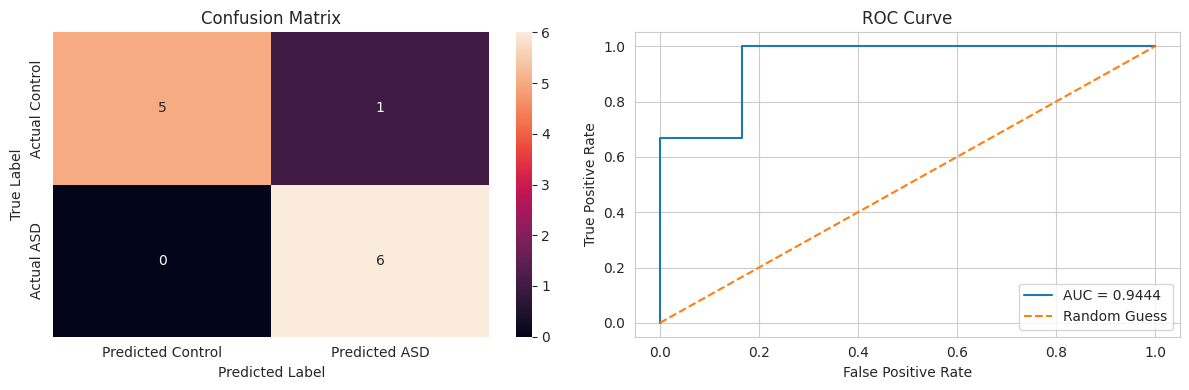

In [ ]:
# STEP 4.3 — Confusion Matrix dan ROC Curve
# Proses ini menampilkan visualisasi evaluasi utama model final.

cm = confusion_matrix(y_test_final, y_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion Matrix
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Predicted Control", "Predicted ASD"],
    yticklabels=["Actual Control", "Actual ASD"],
    ax=axes[0]
)
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test_final, y_test_proba)
roc_auc_value = auc(fpr, tpr)

axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_value:.4f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", label="Random Guess")
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

In [ ]:
# STEP 4.4 — Tabel prediksi dan simpan hasil
# Proses ini menyimpan metrik evaluasi dan prediksi tiap sampel test.

prediction_result_df = pd.DataFrame({
    "Sample_ID": id_test_final.values,
    "Actual_Target": y_test_final.values,
    "Predicted_Target": y_test_pred,
    "ASD_Probability": y_test_proba
})

prediction_result_df["Actual_Label"] = prediction_result_df["Actual_Target"].map({
    0: "Control",
    1: "ASD"
})

prediction_result_df["Predicted_Label"] = prediction_result_df["Predicted_Target"].map({
    0: "Control",
    1: "ASD"
})

prediction_result_df["Prediction_Status"] = np.where(
    prediction_result_df["Actual_Target"] == prediction_result_df["Predicted_Target"],
    "Correct",
    "Incorrect"
)

display(prediction_result_df.sort_values("ASD_Probability", ascending=False))

# Simpan hasil
os.makedirs(output_dir, exist_ok=True)

final_metrics_df.to_csv(f"{output_dir}/15_final_model_metrics.csv", index=False)
prediction_result_df.to_csv(f"{output_dir}/16_final_prediction_per_sample.csv", index=False)

print("Hasil Step 4 berhasil disimpan di:")
print(output_dir)

,Sample_ID,Actual_Target,Predicted_Target,ASD_Probability,Actual_Label,Predicted_Label,Prediction_Status
10,B156,1,1,0.819417,ASD,ASD,Correct
1,B158,1,1,0.807500,ASD,ASD,Correct
8,B143,1,1,0.750000,ASD,ASD,Correct
2,B99,1,1,0.638167,ASD,ASD,Correct
9,A93,0,1,0.595000,Control,ASD,Incorrect
6,B28,1,1,0.590417,ASD,ASD,Correct
4,B103,1,1,0.504750,ASD,ASD,Correct
11,A101,0,0,0.481917,Control,Control,Correct
0,A67,0,0,0.378583,Control,Control,Correct
3,A52,0,0,0.206667,Control,Control,Correct


Hasil Step 4 berhasil disimpan di:
/content/drive/MyDrive/MAGANG/artikel/analisis perilaku anak autis/output_ml_asd


# FEATURE IMPORTANCE RANDOM FOREST

In [ ]:
# STEP 5.1 — Feature Importance Random Forest
# Proses ini mengambil nilai feature importance dari model Random Forest final.

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

output_dir = "/content/drive/MyDrive/MAGANG/artikel/analisis perilaku anak autis/output_ml_asd"
final_split = "80:20"

# Load ulang jika runtime Colab reset
if "final_model" not in globals():
    final_model = joblib.load(f"{output_dir}/final_random_forest_tuned_80_20.joblib")

if "splits" not in globals():
    splits = joblib.load(f"{output_dir}/step2_splits.joblib")

# Mengambil bagian preprocessing dan model Random Forest dari pipeline final
final_preprocessor = final_model.named_steps["preprocess"]
final_rf = final_model.named_steps["model"]

# Mengambil nama fitur yang lolos preprocessing
selected_features = final_preprocessor.get_feature_names_out()

# Mengambil nilai feature importance dari Random Forest
feature_importance_values = final_rf.feature_importances_

feature_importance_df = pd.DataFrame({
    "Bacteria": selected_features,
    "Feature_Importance": feature_importance_values
})

feature_importance_df = feature_importance_df.sort_values(
    "Feature_Importance",
    ascending=False
).reset_index(drop=True)

feature_importance_df["Rank"] = feature_importance_df.index + 1

feature_importance_df = feature_importance_df[
    ["Rank", "Bacteria", "Feature_Importance"]
]

print("Jumlah fitur yang dianalisis:", feature_importance_df.shape[0])

display(feature_importance_df.head(20))

Jumlah fitur yang dianalisis: 3547


,Rank,Bacteria,Feature_Importance
0,1,g__Prevotella;s__Prevotella sp. CAG:1185,0.036978
1,2,g__Bacteroides;s__Bacteroides sp. CAG:702,0.017868
2,3,g__Prevotella;s__Prevotella stercorea CAG:629,0.016850
3,4,g__Prevotella;s__Prevotella ruminicola,0.014332
4,5,g__Prevotella;s__Prevotella sp. CAG:755,0.013009
5,6,g__Prevotella;s__Prevotella sp. P4-65,0.012467
6,7,g__Bacteroides;s__Bacteroides sp. CAG:443,0.012423
7,8,g__Prevotella;s__Prevotella sp. 109,0.012135
8,9,g__Bacteroides;s__Bacteroides sp. CAG:598,0.012061
9,10,g__Bacteroides;s__Bacteroides coprophilus CAG:333,0.011763


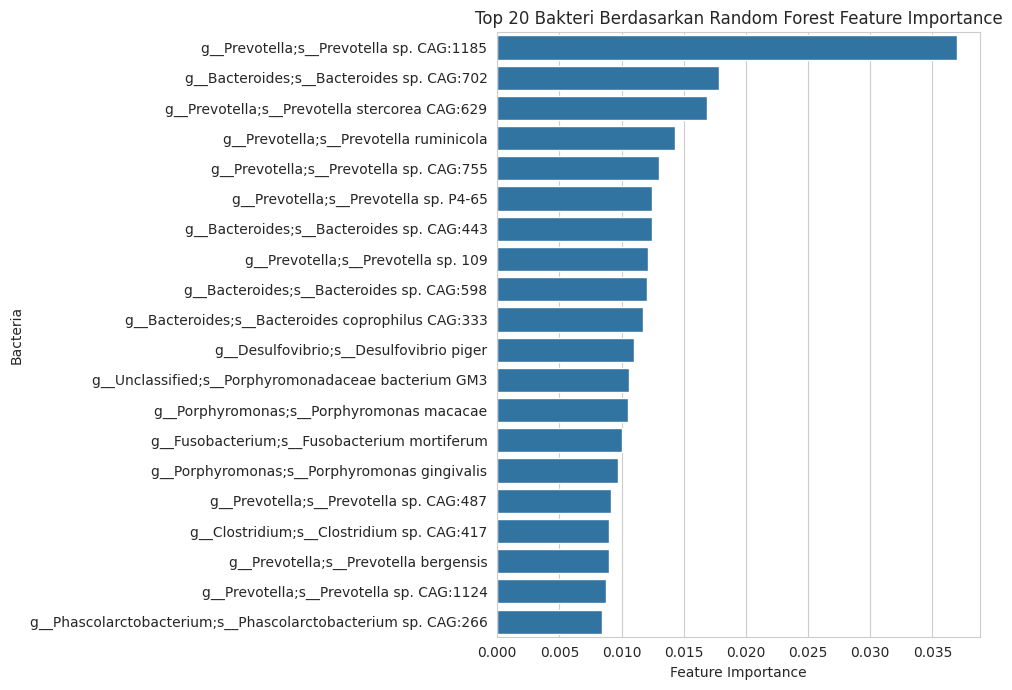

In [ ]:
# STEP 5.2 — Visualisasi Top 20 Feature Importance
# Proses ini menampilkan 20 bakteri dengan nilai feature importance tertinggi.

top_n = 20

top_feature_importance_df = feature_importance_df.head(top_n).copy()

plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_feature_importance_df,
    x="Feature_Importance",
    y="Bacteria"
)
plt.title("Top 20 Bakteri Berdasarkan Random Forest Feature Importance")
plt.xlabel("Feature Importance")
plt.ylabel("Bacteria")
plt.tight_layout()
plt.show()

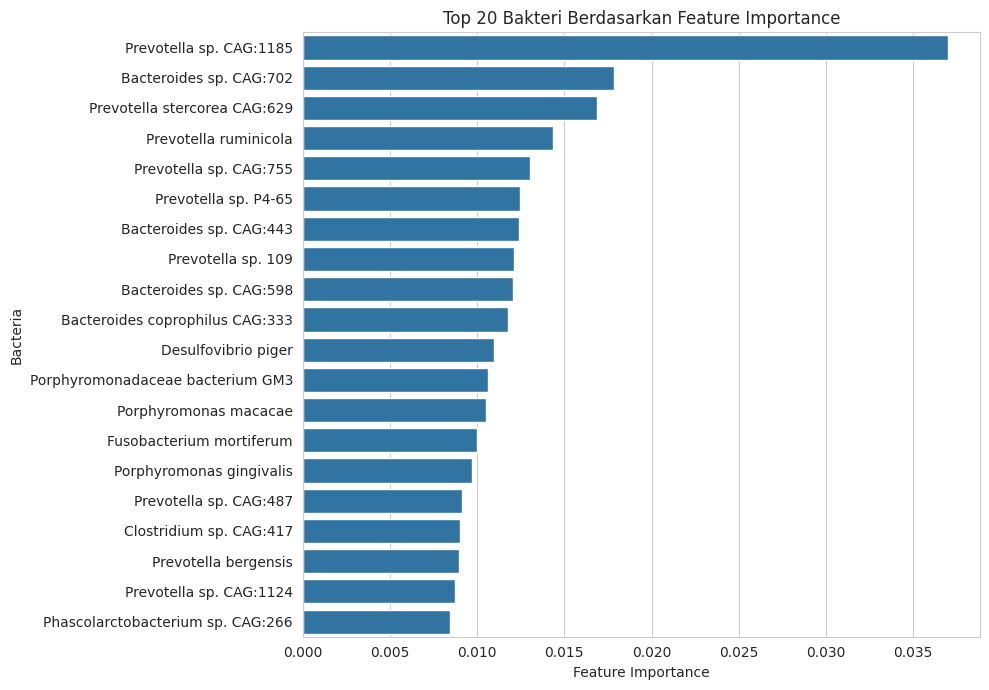

,Rank,Bacteria,Bacteria_Short,Feature_Importance
0,1,g__Prevotella;s__Prevotella sp. CAG:1185,Prevotella sp. CAG:1185,0.036978
1,2,g__Bacteroides;s__Bacteroides sp. CAG:702,Bacteroides sp. CAG:702,0.017868
2,3,g__Prevotella;s__Prevotella stercorea CAG:629,Prevotella stercorea CAG:629,0.016850
3,4,g__Prevotella;s__Prevotella ruminicola,Prevotella ruminicola,0.014332
4,5,g__Prevotella;s__Prevotella sp. CAG:755,Prevotella sp. CAG:755,0.013009
5,6,g__Prevotella;s__Prevotella sp. P4-65,Prevotella sp. P4-65,0.012467
6,7,g__Bacteroides;s__Bacteroides sp. CAG:443,Bacteroides sp. CAG:443,0.012423
7,8,g__Prevotella;s__Prevotella sp. 109,Prevotella sp. 109,0.012135
8,9,g__Bacteroides;s__Bacteroides sp. CAG:598,Bacteroides sp. CAG:598,0.012061
9,10,g__Bacteroides;s__Bacteroides coprophilus CAG:333,Bacteroides coprophilus CAG:333,0.011763


In [ ]:
# STEP 5.3 — Membuat nama bakteri versi pendek
# Proses ini memendekkan nama taxonomy agar tabel dan grafik lebih mudah dibaca.

def shorten_taxonomy(taxonomy):
    taxonomy = str(taxonomy)

    if "s__" in taxonomy:
        return taxonomy.split("s__")[-1]

    if "g__" in taxonomy:
        return taxonomy.split("g__")[-1]

    return taxonomy[:80]

feature_importance_df["Bacteria_Short"] = feature_importance_df["Bacteria"].apply(shorten_taxonomy)

top_feature_importance_df = feature_importance_df.head(top_n).copy()

plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_feature_importance_df,
    x="Feature_Importance",
    y="Bacteria_Short"
)
plt.title("Top 20 Bakteri Berdasarkan Feature Importance")
plt.xlabel("Feature Importance")
plt.ylabel("Bacteria")
plt.tight_layout()
plt.show()

display(top_feature_importance_df[[
    "Rank",
    "Bacteria",
    "Bacteria_Short",
    "Feature_Importance"
]])

,Rank,Bacteria,Feature_Importance,Bacteria_Short,Cumulative_Importance
0,1,g__Prevotella;s__Prevotella sp. CAG:1185,0.036978,Prevotella sp. CAG:1185,0.036978
1,2,g__Bacteroides;s__Bacteroides sp. CAG:702,0.017868,Bacteroides sp. CAG:702,0.054845
2,3,g__Prevotella;s__Prevotella stercorea CAG:629,0.016850,Prevotella stercorea CAG:629,0.071695
3,4,g__Prevotella;s__Prevotella ruminicola,0.014332,Prevotella ruminicola,0.086028
4,5,g__Prevotella;s__Prevotella sp. CAG:755,0.013009,Prevotella sp. CAG:755,0.099037
5,6,g__Prevotella;s__Prevotella sp. P4-65,0.012467,Prevotella sp. P4-65,0.111504
6,7,g__Bacteroides;s__Bacteroides sp. CAG:443,0.012423,Bacteroides sp. CAG:443,0.123927
7,8,g__Prevotella;s__Prevotella sp. 109,0.012135,Prevotella sp. 109,0.136062
8,9,g__Bacteroides;s__Bacteroides sp. CAG:598,0.012061,Bacteroides sp. CAG:598,0.148123
9,10,g__Bacteroides;s__Bacteroides coprophilus CAG:333,0.011763,Bacteroides coprophilus CAG:333,0.159886


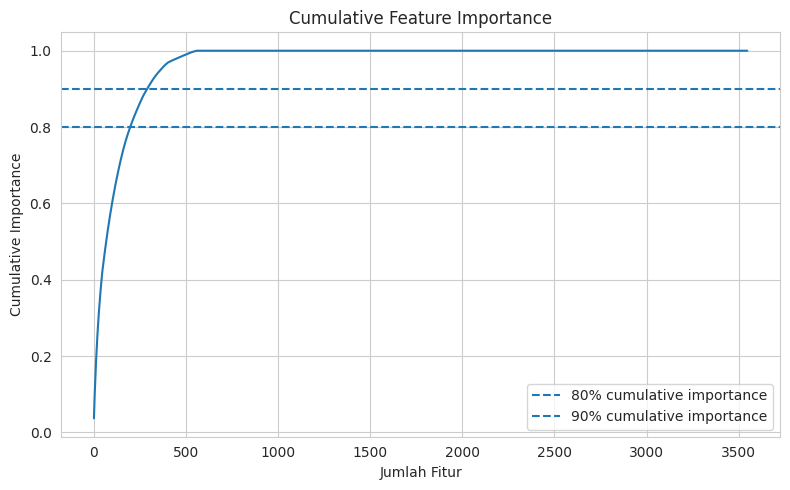

Jumlah fitur untuk mencapai sekitar 80% importance: 197
Jumlah fitur untuk mencapai sekitar 90% importance: 289


In [ ]:
# STEP 5.4 — Kumulatif Feature Importance
# Proses ini menghitung akumulasi kontribusi fitur untuk melihat seberapa tersebar kontribusi bakteri dalam model.

feature_importance_df["Cumulative_Importance"] = feature_importance_df["Feature_Importance"].cumsum()

display(feature_importance_df.head(30))

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(feature_importance_df) + 1),
    feature_importance_df["Cumulative_Importance"]
)
plt.axhline(0.80, linestyle="--", label="80% cumulative importance")
plt.axhline(0.90, linestyle="--", label="90% cumulative importance")
plt.title("Cumulative Feature Importance")
plt.xlabel("Jumlah Fitur")
plt.ylabel("Cumulative Importance")
plt.legend()
plt.tight_layout()
plt.show()

n_features_80 = (feature_importance_df["Cumulative_Importance"] <= 0.80).sum()
n_features_90 = (feature_importance_df["Cumulative_Importance"] <= 0.90).sum()

print("Jumlah fitur untuk mencapai sekitar 80% importance:", n_features_80)
print("Jumlah fitur untuk mencapai sekitar 90% importance:", n_features_90)

In [ ]:
# STEP 5.4b — Hitung jumlah fitur yang mencapai 80% dan 90% cumulative importance
# Proses ini menghitung jumlah fitur minimum yang dibutuhkan untuk mencapai 80% dan 90% kontribusi kumulatif.

n_features_80 = np.argmax(feature_importance_df["Cumulative_Importance"] >= 0.80) + 1
n_features_90 = np.argmax(feature_importance_df["Cumulative_Importance"] >= 0.90) + 1

print("Jumlah fitur minimum untuk mencapai 80% importance:", n_features_80)
print("Jumlah fitur minimum untuk mencapai 90% importance:", n_features_90)

Jumlah fitur minimum untuk mencapai 80% importance: 198
Jumlah fitur minimum untuk mencapai 90% importance: 290


In [ ]:
# STEP 5.5 — Simpan hasil Feature Importance
# Proses ini menyimpan hasil Random Forest Feature Importance untuk analisis lanjutan.

os.makedirs(output_dir, exist_ok=True)

feature_importance_df.to_csv(
    f"{output_dir}/20_random_forest_feature_importance.csv",
    index=False
)

top_feature_importance_df.to_csv(
    f"{output_dir}/21_top20_random_forest_feature_importance.csv",
    index=False
)

print("Output Step 5 berhasil disimpan di:")
print(output_dir)

Output Step 5 berhasil disimpan di:
/content/drive/MyDrive/MAGANG/artikel/analisis perilaku anak autis/output_ml_asd


# SHAP ANALYSIS

In [ ]:
# STEP 6.1 — Install dan import SHAP
# Proses ini menyiapkan library SHAP untuk menjelaskan kontribusi fitur bakteri terhadap prediksi model.

!pip -q install shap

import os
import joblib
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Library SHAP siap digunakan.")

Library SHAP siap digunakan.


In [ ]:
# STEP 6.2 — Load model final dan data test
# Proses ini memastikan model Random Forest final dan data split 80:20 tersedia untuk analisis SHAP.

output_dir = "/content/drive/MyDrive/MAGANG/artikel/analisis perilaku anak autis/output_ml_asd"
final_split = "80:20"

if "final_model" not in globals():
    final_model = joblib.load(f"{output_dir}/final_random_forest_tuned_80_20.joblib")

if "splits" not in globals():
    splits = joblib.load(f"{output_dir}/step2_splits.joblib")

X_train_final = splits[final_split]["X_train"]
X_test_final = splits[final_split]["X_test"]
y_test_final = splits[final_split]["y_test"]

print("X_train:", X_train_final.shape)
print("X_test :", X_test_final.shape)

X_train: (48, 5619)
X_test : (12, 5619)


In [ ]:
# STEP 6.3 — Transform data untuk SHAP
# Proses ini mengubah data train dan test sesuai preprocessing final model.

final_preprocessor = final_model.named_steps["preprocess"]
final_rf = final_model.named_steps["model"]

X_train_prep = final_preprocessor.transform(X_train_final)
X_test_prep = final_preprocessor.transform(X_test_final)

print("X_train setelah preprocessing:", X_train_prep.shape)
print("X_test setelah preprocessing :", X_test_prep.shape)

X_train setelah preprocessing: (48, 3547)
X_test setelah preprocessing : (12, 3547)


In [ ]:
# STEP 6.4 — Membatasi fitur SHAP ke Top 30
# Proses ini mengambil 30 bakteri terpenting dari Random Forest Feature Importance agar SHAP lebih ringan.

if "feature_importance_df" not in globals():
    feature_importance_df = pd.read_csv(f"{output_dir}/20_random_forest_feature_importance.csv")

top_shap_features = feature_importance_df.head(30)["Bacteria"].tolist()

X_train_shap = X_train_prep[top_shap_features].copy()
X_test_shap = X_test_prep[top_shap_features].copy()

print("Shape data SHAP:", X_test_shap.shape)
display(X_test_shap.head())

Shape data SHAP: (12, 30)


,g__Prevotella;s__Prevotella sp. CAG:1185,g__Bacteroides;s__Bacteroides sp. CAG:702,g__Prevotella;s__Prevotella stercorea CAG:629,g__Prevotella;s__Prevotella ruminicola,g__Prevotella;s__Prevotella sp. CAG:755,g__Prevotella;s__Prevotella sp. P4-65,g__Bacteroides;s__Bacteroides sp. CAG:443,g__Prevotella;s__Prevotella sp. 109,g__Bacteroides;s__Bacteroides sp. CAG:598,g__Bacteroides;s__Bacteroides coprophilus CAG:333,g__Desulfovibrio;s__Desulfovibrio piger,g__Unclassified;s__Porphyromonadaceae bacterium GM3,g__Porphyromonas;s__Porphyromonas macacae,g__Fusobacterium;s__Fusobacterium mortiferum,g__Porphyromonas;s__Porphyromonas gingivalis,g__Prevotella;s__Prevotella sp. CAG:487,g__Clostridium;s__Clostridium sp. CAG:417,g__Prevotella;s__Prevotella bergensis,g__Prevotella;s__Prevotella sp. CAG:1124,g__Phascolarctobacterium;s__Phascolarctobacterium sp. CAG:266,g__Bacteroides;s__Bacteroides finegoldii,g__Bacteroides;s__Bacteroides stercoris CAG:120,g__Prevotella;s__Prevotella sp. MA2016,g__Alistipes;s__Alistipes sp. CAG:831,g__Parabacteroides;s__Parabacteroides sp. CAG:409,g__Bacteroides;s__Bacteroides pyogenes,g__Bacteroides;s__Bacteroides paurosaccharolyticus,g__Prevotella;s__Prevotella sp. CAG:1058,g__Prevotella;s__Prevotella sp. oral taxon 317,g__Prevotella;s__Prevotella nanceiensis
10,0.000068,0.000034,0.003468,0.000119,0.000034,0.000085,0.000068,0.000187,0.000034,0.000034,0.000187,0.000102,0.000051,0.000034,0.000051,0.000017,0.000000,0.000017,0.000102,0.000034,0.006715,0.000170,0.000017,0.000051,0.000153,0.000357,0.000000,0.000799,0.000034,0.000034
58,0.000017,0.000052,0.000017,0.000105,0.000000,0.000052,0.000070,0.000017,0.000000,0.000017,0.000017,0.000000,0.000000,0.000017,0.000000,0.000017,0.000017,0.000000,0.000000,0.000052,0.000907,0.000105,0.000000,0.000017,0.000000,0.000122,0.000000,0.000052,0.000000,0.000035
44,0.000022,0.000111,0.000022,0.000022,0.000044,0.000022,0.000044,0.000088,0.000111,0.000022,0.000066,0.000088,0.000000,0.000022,0.000000,0.000022,0.000354,0.000000,0.000000,0.000088,0.000951,0.000354,0.000022,0.000000,0.000044,0.000265,0.000044,0.000044,0.000000,0.000022
6,0.000286,0.000275,0.000275,0.000137,0.000126,0.000046,0.000401,0.000928,0.000092,0.000183,0.000092,0.000034,0.000023,0.000069,0.000046,0.000126,0.000825,0.000023,0.000080,0.000298,0.001844,0.000653,0.000023,0.000046,0.000046,0.000218,0.000034,0.000103,0.000046,0.000046
45,0.000031,0.000071,0.000153,0.000132,0.000041,0.000061,0.000031,0.000092,0.000020,0.000010,0.001465,0.000000,0.000000,0.000010,0.000041,0.000010,0.000051,0.000031,0.000081,0.000031,0.001160,0.000590,0.000031,0.000081,0.000041,0.000468,0.000031,0.000092,0.000031,0.000031


In [ ]:
# STEP 6.5 — Model interpretasi SHAP berbasis Top 30 fitur
# Proses ini melatih Random Forest interpretasi agar SHAP lebih ringan dan tidak error karena jumlah fitur berbeda.

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

rf_shap_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    max_features="sqrt",
    min_samples_leaf=2,
    n_jobs=-1
)

rf_shap_model.fit(X_train_shap, splits[final_split]["y_train"])

y_pred_shap_model = rf_shap_model.predict(X_test_shap)
y_proba_shap_model = rf_shap_model.predict_proba(X_test_shap)[:, 1]

shap_model_check = pd.DataFrame([{
    "Model": "Random Forest interpretasi Top 30",
    "Accuracy": accuracy_score(y_test_final, y_pred_shap_model),
    "F1-Score": f1_score(y_test_final, y_pred_shap_model),
    "ROC-AUC": roc_auc_score(y_test_final, y_proba_shap_model)
}])

display(shap_model_check)

,Model,Accuracy,F1-Score,ROC-AUC
0,Random Forest interpretasi Top 30,0.916667,0.923077,0.944444


In [ ]:
# STEP 6.6 — Menghitung SHAP values dengan format aman
# Proses ini menghitung nilai SHAP dan memastikan yang digunakan adalah kontribusi untuk kelas ASD.

explainer = shap.TreeExplainer(rf_shap_model)

shap_values_raw = explainer.shap_values(X_test_shap)

print("Tipe shap_values_raw:", type(shap_values_raw))

# Kasus 1: SHAP mengembalikan list [kelas 0, kelas 1]
if isinstance(shap_values_raw, list):
    shap_values_asd = shap_values_raw[1]

# Kasus 2: SHAP mengembalikan array 3D: sampel × fitur × kelas
elif isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 3:
    shap_values_asd = shap_values_raw[:, :, 1]

# Kasus 3: SHAP sudah mengembalikan array 2D: sampel × fitur
elif isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 2:
    shap_values_asd = shap_values_raw

else:
    raise ValueError("Format SHAP values tidak dikenali.")

shap_values_asd = np.array(shap_values_asd)

print("Shape X_test_shap:", X_test_shap.shape)
print("Shape shap_values_asd:", shap_values_asd.shape)

Tipe shap_values_raw: <class 'numpy.ndarray'>
Shape X_test_shap: (12, 30)
Shape shap_values_asd: (12, 30)


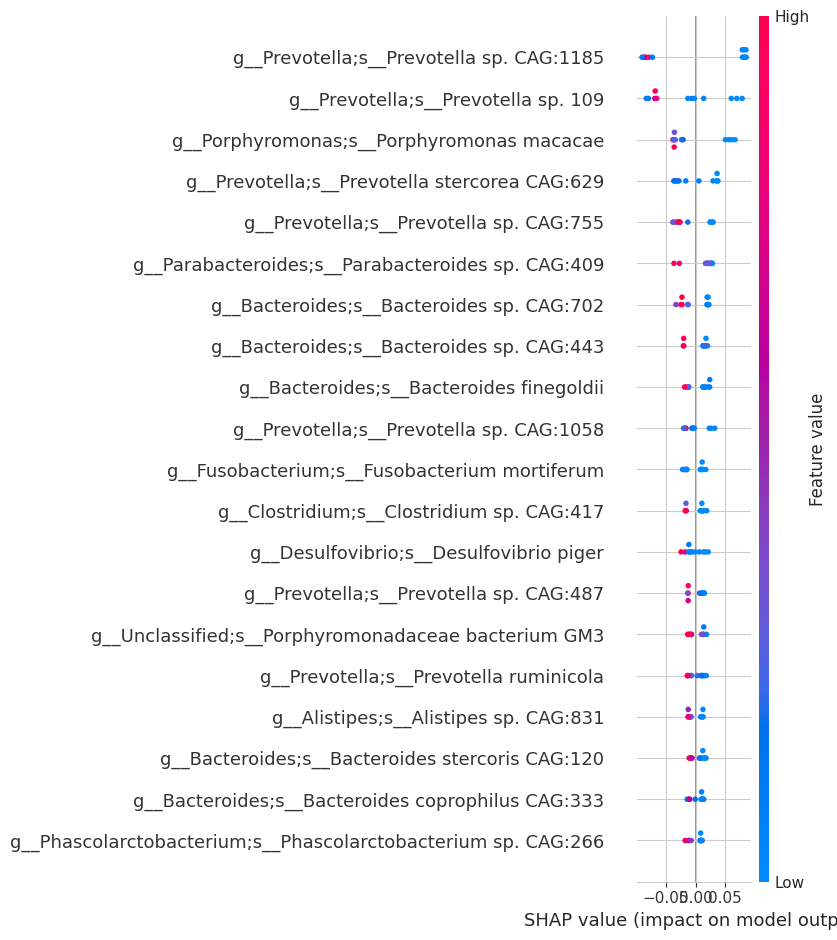

In [ ]:
# STEP 6.7 — SHAP summary plot
# Proses ini menampilkan arah dan kekuatan kontribusi bakteri terhadap prediksi ASD.

shap.summary_plot(
    shap_values_asd,
    X_test_shap,
    plot_type="dot",
    max_display=20
)

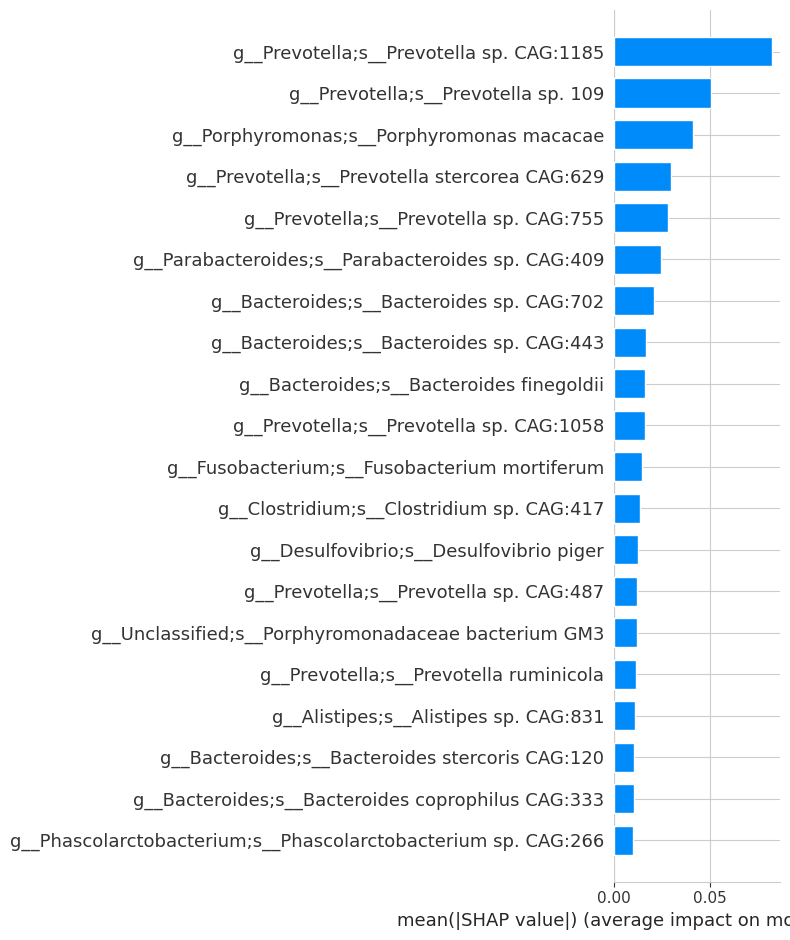

In [ ]:
# STEP 6.8 — SHAP bar plot
# Proses ini menampilkan ranking bakteri berdasarkan rata-rata kontribusi absolut SHAP.

shap.summary_plot(
    shap_values_asd,
    X_test_shap,
    plot_type="bar",
    max_display=20
)

In [ ]:
# STEP 6.9 — Tabel Top SHAP Bacteria
# Proses ini membuat tabel bakteri paling penting berdasarkan mean absolute SHAP value.

mean_abs_shap = np.abs(shap_values_asd).mean(axis=0)

mean_abs_shap = np.ravel(mean_abs_shap)

shap_importance_df = pd.DataFrame({
    "Bacteria": list(X_test_shap.columns),
    "Mean_Abs_SHAP": mean_abs_shap
})

shap_importance_df["Bacteria_Short"] = shap_importance_df["Bacteria"].apply(shorten_taxonomy)

shap_importance_df = shap_importance_df.sort_values(
    "Mean_Abs_SHAP",
    ascending=False
).reset_index(drop=True)

shap_importance_df["Rank"] = shap_importance_df.index + 1

shap_importance_df = shap_importance_df[
    ["Rank", "Bacteria", "Bacteria_Short", "Mean_Abs_SHAP"]
]

display(shap_importance_df.head(20))

,Rank,Bacteria,Bacteria_Short,Mean_Abs_SHAP
0,1,g__Prevotella;s__Prevotella sp. CAG:1185,Prevotella sp. CAG:1185,0.082256
1,2,g__Prevotella;s__Prevotella sp. 109,Prevotella sp. 109,0.050715
2,3,g__Porphyromonas;s__Porphyromonas macacae,Porphyromonas macacae,0.041304
3,4,g__Prevotella;s__Prevotella stercorea CAG:629,Prevotella stercorea CAG:629,0.029874
4,5,g__Prevotella;s__Prevotella sp. CAG:755,Prevotella sp. CAG:755,0.028337
5,6,g__Parabacteroides;s__Parabacteroides sp. CAG:409,Parabacteroides sp. CAG:409,0.024438
6,7,g__Bacteroides;s__Bacteroides sp. CAG:702,Bacteroides sp. CAG:702,0.021032
7,8,g__Bacteroides;s__Bacteroides sp. CAG:443,Bacteroides sp. CAG:443,0.016836
8,9,g__Bacteroides;s__Bacteroides finegoldii,Bacteroides finegoldii,0.016273
9,10,g__Prevotella;s__Prevotella sp. CAG:1058,Prevotella sp. CAG:1058,0.015958


In [ ]:
# STEP 6.10 — Arah kontribusi SHAP
# Proses ini melihat apakah rata-rata kontribusi bakteri lebih mendorong prediksi ke ASD atau Control.

mean_shap = shap_values_asd.mean(axis=0)

mean_shap = np.ravel(mean_shap)
mean_abs_shap = np.ravel(mean_abs_shap)

shap_direction_df = pd.DataFrame({
    "Bacteria": list(X_test_shap.columns),
    "Mean_SHAP": mean_shap,
    "Mean_Abs_SHAP": mean_abs_shap
})

shap_direction_df["Bacteria_Short"] = shap_direction_df["Bacteria"].apply(shorten_taxonomy)

shap_direction_df["Direction"] = np.where(
    shap_direction_df["Mean_SHAP"] > 0,
    "Mendorong prediksi ASD",
    "Mendorong prediksi Control"
)

shap_direction_df = shap_direction_df.sort_values(
    "Mean_Abs_SHAP",
    ascending=False
).reset_index(drop=True)

shap_direction_df["Rank"] = shap_direction_df.index + 1

display(shap_direction_df[
    ["Rank", "Bacteria", "Bacteria_Short", "Mean_SHAP", "Mean_Abs_SHAP", "Direction"]
].head(20))

,Rank,Bacteria,Bacteria_Short,Mean_SHAP,Mean_Abs_SHAP,Direction
0,1,g__Prevotella;s__Prevotella sp. CAG:1185,Prevotella sp. CAG:1185,0.013252,0.082256,Mendorong prediksi ASD
1,2,g__Prevotella;s__Prevotella sp. 109,Prevotella sp. 109,-0.013913,0.050715,Mendorong prediksi Control
2,3,g__Porphyromonas;s__Porphyromonas macacae,Porphyromonas macacae,-0.002478,0.041304,Mendorong prediksi Control
3,4,g__Prevotella;s__Prevotella stercorea CAG:629,Prevotella stercorea CAG:629,-0.000030,0.029874,Mendorong prediksi Control
4,5,g__Prevotella;s__Prevotella sp. CAG:755,Prevotella sp. CAG:755,-0.010591,0.028337,Mendorong prediksi Control
5,6,g__Parabacteroides;s__Parabacteroides sp. CAG:409,Parabacteroides sp. CAG:409,0.013738,0.024438,Mendorong prediksi ASD
6,7,g__Bacteroides;s__Bacteroides sp. CAG:702,Bacteroides sp. CAG:702,-0.000698,0.021032,Mendorong prediksi Control
7,8,g__Bacteroides;s__Bacteroides sp. CAG:443,Bacteroides sp. CAG:443,0.006659,0.016836,Mendorong prediksi ASD
8,9,g__Bacteroides;s__Bacteroides finegoldii,Bacteroides finegoldii,0.004287,0.016273,Mendorong prediksi ASD
9,10,g__Prevotella;s__Prevotella sp. CAG:1058,Prevotella sp. CAG:1058,-0.002488,0.015958,Mendorong prediksi Control


In [ ]:
# STEP 6.11 — Simpan hasil SHAP
# Proses ini menyimpan tabel SHAP untuk interpretasi biologis dan rekomendasi pola makan.

shap_importance_df.to_csv(
    f"{output_dir}/24_shap_importance_top30.csv",
    index=False
)

shap_direction_df.to_csv(
    f"{output_dir}/25_shap_direction_top30.csv",
    index=False
)

shap_model_check.to_csv(
    f"{output_dir}/26_shap_interpretation_model_check.csv",
    index=False
)

print("Output Step 6 berhasil disimpan di:")
print(output_dir)

Output Step 6 berhasil disimpan di:
/content/drive/MyDrive/MAGANG/artikel/analisis perilaku anak autis/output_ml_asd


#Feature Importance + SHAP Direction

In [ ]:
# STEP 7.1 — Menggabungkan Feature Importance dan SHAP Direction
# Proses ini menggabungkan ranking Random Forest Feature Importance dan SHAP agar kandidat bakteri penting lebih kuat.

rf_top_df = feature_importance_df[[
    "Rank",
    "Bacteria",
    "Bacteria_Short",
    "Feature_Importance"
]].copy()

rf_top_df = rf_top_df.rename(columns={
    "Rank": "RF_Rank"
})

shap_top_df = shap_direction_df[[
    "Rank",
    "Bacteria",
    "Mean_SHAP",
    "Mean_Abs_SHAP",
    "Direction"
]].copy()

shap_top_df = shap_top_df.rename(columns={
    "Rank": "SHAP_Rank"
})

combined_interpretation_df = rf_top_df.merge(
    shap_top_df,
    on="Bacteria",
    how="inner"
)

combined_interpretation_df["Average_Rank"] = (
    combined_interpretation_df["RF_Rank"] +
    combined_interpretation_df["SHAP_Rank"]
) / 2

combined_interpretation_df = combined_interpretation_df.sort_values(
    "Average_Rank",
    ascending=True
).reset_index(drop=True)

display(combined_interpretation_df.head(20))

,RF_Rank,Bacteria,Bacteria_Short,Feature_Importance,SHAP_Rank,Mean_SHAP,Mean_Abs_SHAP,Direction,Average_Rank
0,1,g__Prevotella;s__Prevotella sp. CAG:1185,Prevotella sp. CAG:1185,0.036978,1,0.013252,0.082256,Mendorong prediksi ASD,1.0
1,3,g__Prevotella;s__Prevotella stercorea CAG:629,Prevotella stercorea CAG:629,0.016850,4,-0.000030,0.029874,Mendorong prediksi Control,3.5
2,2,g__Bacteroides;s__Bacteroides sp. CAG:702,Bacteroides sp. CAG:702,0.017868,7,-0.000698,0.021032,Mendorong prediksi Control,4.5
3,5,g__Prevotella;s__Prevotella sp. CAG:755,Prevotella sp. CAG:755,0.013009,5,-0.010591,0.028337,Mendorong prediksi Control,5.0
4,8,g__Prevotella;s__Prevotella sp. 109,Prevotella sp. 109,0.012135,2,-0.013913,0.050715,Mendorong prediksi Control,5.0
5,7,g__Bacteroides;s__Bacteroides sp. CAG:443,Bacteroides sp. CAG:443,0.012423,8,0.006659,0.016836,Mendorong prediksi ASD,7.5
6,13,g__Porphyromonas;s__Porphyromonas macacae,Porphyromonas macacae,0.010523,3,-0.002478,0.041304,Mendorong prediksi Control,8.0
7,4,g__Prevotella;s__Prevotella ruminicola,Prevotella ruminicola,0.014332,16,0.001832,0.011227,Mendorong prediksi ASD,10.0
8,11,g__Desulfovibrio;s__Desulfovibrio piger,Desulfovibrio piger,0.010969,13,-0.002881,0.012366,Mendorong prediksi Control,12.0
9,14,g__Fusobacterium;s__Fusobacterium mortiferum,Fusobacterium mortiferum,0.010003,11,-0.003273,0.014413,Mendorong prediksi Control,12.5


In [ ]:
# STEP 7.2 — Simpan tabel kandidat bakteri penting
# Proses ini menyimpan tabel gabungan RF Feature Importance dan SHAP Direction.

combined_interpretation_df.to_csv(
    f"{output_dir}/27_combined_rf_shap_interpretation.csv",
    index=False
)

print("Tabel kandidat bakteri penting berhasil disimpan di:")
print(f"{output_dir}/27_combined_rf_shap_interpretation.csv")

Tabel kandidat bakteri penting berhasil disimpan di:
/content/drive/MyDrive/MAGANG/artikel/analisis perilaku anak autis/output_ml_asd/27_combined_rf_shap_interpretation.csv


#**INTERPRETASI BIOLOGIS & REKOMENDASI POLA MAKAN**

In [ ]:
# STEP 8.1 — Load data hasil RF + SHAP
# Proses ini memastikan tabel gabungan feature importance dan SHAP tersedia.

import os
import pandas as pd
import numpy as np

output_dir = "/content/drive/MyDrive/MAGANG/artikel/analisis perilaku anak autis/output_ml_asd"

if "combined_interpretation_df" not in globals():
    combined_interpretation_df = pd.read_csv(
        f"{output_dir}/27_combined_rf_shap_interpretation.csv"
    )
    print("combined_interpretation_df dibaca ulang dari Google Drive.")
else:
    print("combined_interpretation_df sudah tersedia.")

print("Shape data interpretasi:", combined_interpretation_df.shape)

display(combined_interpretation_df.head(10))

combined_interpretation_df sudah tersedia.
Shape data interpretasi: (30, 9)


,RF_Rank,Bacteria,Bacteria_Short,Feature_Importance,SHAP_Rank,Mean_SHAP,Mean_Abs_SHAP,Direction,Average_Rank
0,1,g__Prevotella;s__Prevotella sp. CAG:1185,Prevotella sp. CAG:1185,0.036978,1,0.013252,0.082256,Mendorong prediksi ASD,1.0
1,3,g__Prevotella;s__Prevotella stercorea CAG:629,Prevotella stercorea CAG:629,0.016850,4,-0.000030,0.029874,Mendorong prediksi Control,3.5
2,2,g__Bacteroides;s__Bacteroides sp. CAG:702,Bacteroides sp. CAG:702,0.017868,7,-0.000698,0.021032,Mendorong prediksi Control,4.5
3,5,g__Prevotella;s__Prevotella sp. CAG:755,Prevotella sp. CAG:755,0.013009,5,-0.010591,0.028337,Mendorong prediksi Control,5.0
4,8,g__Prevotella;s__Prevotella sp. 109,Prevotella sp. 109,0.012135,2,-0.013913,0.050715,Mendorong prediksi Control,5.0
5,7,g__Bacteroides;s__Bacteroides sp. CAG:443,Bacteroides sp. CAG:443,0.012423,8,0.006659,0.016836,Mendorong prediksi ASD,7.5
6,13,g__Porphyromonas;s__Porphyromonas macacae,Porphyromonas macacae,0.010523,3,-0.002478,0.041304,Mendorong prediksi Control,8.0
7,4,g__Prevotella;s__Prevotella ruminicola,Prevotella ruminicola,0.014332,16,0.001832,0.011227,Mendorong prediksi ASD,10.0
8,11,g__Desulfovibrio;s__Desulfovibrio piger,Desulfovibrio piger,0.010969,13,-0.002881,0.012366,Mendorong prediksi Control,12.0
9,14,g__Fusobacterium;s__Fusobacterium mortiferum,Fusobacterium mortiferum,0.010003,11,-0.003273,0.014413,Mendorong prediksi Control,12.5


In [ ]:
# STEP 8.2 — Fungsi interpretasi biologis
# Proses ini mengelompokkan bakteri penting berdasarkan genus atau kelompok biologisnya.

def get_bacteria_group(bacteria):
    name = str(bacteria).lower()

    if "prevotella" in name:
        return "Prevotella"
    elif "bacteroides" in name and "parabacteroides" not in name:
        return "Bacteroides"
    elif "parabacteroides" in name:
        return "Parabacteroides"
    elif "porphyromonas" in name:
        return "Porphyromonas"
    elif "fusobacterium" in name:
        return "Fusobacterium"
    elif "desulfovibrio" in name:
        return "Desulfovibrio"
    elif "clostridium" in name:
        return "Clostridium"
    elif "phascolarctobacterium" in name:
        return "Phascolarctobacterium"
    elif "alistipes" in name:
        return "Alistipes"
    else:
        return "Other / Unclassified"


def get_biological_interpretation(group):
    if group == "Prevotella":
        return (
            "Prevotella merupakan genus bakteri usus yang sering dikaitkan dengan metabolisme "
            "karbohidrat kompleks dan pola makan tinggi serat atau berbasis nabati. Namun, efeknya dapat berbeda antar spesies."
        )

    elif group == "Bacteroides":
        return (
            "Bacteroides merupakan bakteri usus dominan yang berperan dalam metabolisme polisakarida dan nutrien kompleks. "
            "Kelompok ini sering dikaitkan dengan pola makan tinggi protein dan lemak, tetapi juga berperan dalam ekosistem usus normal."
        )

    elif group == "Parabacteroides":
        return (
            "Parabacteroides merupakan bagian dari mikrobiota usus yang berkaitan dengan metabolisme nutrien dan modulasi lingkungan usus."
        )

    elif group == "Porphyromonas":
        return (
            "Porphyromonas sering dibahas sebagai kelompok bakteri yang dapat berperan sebagai pathobiont pada kondisi tertentu, "
            "terutama terkait inflamasi dan kesehatan oral-gut axis."
        )

    elif group == "Fusobacterium":
        return (
            "Fusobacterium dapat berperan sebagai pathobiont dan sering dikaitkan dengan inflamasi atau disbiosis pada beberapa konteks biologis."
        )

    elif group == "Desulfovibrio":
        return (
            "Desulfovibrio merupakan bakteri pereduksi sulfat yang dapat menghasilkan metabolit sulfur dan sering dikaitkan dengan kondisi disbiosis."
        )

    elif group == "Clostridium":
        return (
            "Clostridium merupakan genus besar dengan spesies yang sangat beragam; sebagian anggota terkait fermentasi usus dan produksi metabolit, "
            "tetapi sebagian lain dapat berkaitan dengan disbiosis."
        )

    elif group == "Phascolarctobacterium":
        return (
            "Phascolarctobacterium sering dikaitkan dengan metabolisme short-chain fatty acids, terutama dalam ekosistem fermentasi mikrobiota usus."
        )

    elif group == "Alistipes":
        return (
            "Alistipes merupakan bakteri usus yang dapat berkaitan dengan metabolisme protein dan kondisi inflamasi tertentu, "
            "tetapi interpretasinya bergantung pada konteks penyakit dan spesies."
        )

    else:
        return (
            "Interpretasi biologis spesifik masih terbatas sehingga pembahasan sebaiknya dilakukan secara hati-hati pada tingkat kelompok bakteri."
        )

In [ ]:
# STEP 8.3 — Fungsi rekomendasi pola makan
# Proses ini membuat rekomendasi pola makan pendukung berdasarkan kelompok bakteri dan arah kontribusi SHAP.

def get_diet_recommendation(group, direction):
    if group == "Prevotella":
        return (
            "Pertimbangkan pola makan seimbang kaya serat dari sayur, buah, kacang-kacangan, dan biji-bijian utuh. "
            "Namun, jangan menyimpulkan bahwa semua Prevotella selalu baik atau buruk karena efeknya dapat spesifik spesies."
        )

    elif group == "Bacteroides":
        return (
            "Dukung pola makan seimbang dengan variasi serat, protein berkualitas, dan pembatasan lemak jenuh berlebihan. "
            "Tujuannya menjaga keseimbangan mikrobiota, bukan menekan satu genus tertentu."
        )

    elif group == "Parabacteroides":
        return (
            "Dukung konsumsi serat pangan, makanan beragam, dan pola makan rendah ultra-proses untuk menjaga stabilitas mikrobiota usus."
        )

    elif group in ["Porphyromonas", "Fusobacterium"]:
        return (
            "Dukung pola makan anti-inflamasi secara umum, seperti cukup sayur, buah, serat, dan membatasi gula sederhana serta makanan ultra-proses. "
            "Perhatikan juga kesehatan oral karena beberapa bakteri kelompok ini berkaitan dengan ekosistem mulut."
        )

    elif group == "Desulfovibrio":
        return (
            "Pertimbangkan pola makan tinggi serat dan seimbang, serta membatasi makanan ultra-proses dan lemak jenuh berlebihan. "
            "Interpretasi tetap hati-hati karena hubungan diet dengan Desulfovibrio bersifat kompleks."
        )

    elif group in ["Clostridium", "Phascolarctobacterium"]:
        return (
            "Dukung asupan serat fermentabel seperti oat, legum, sayur, buah, dan whole grain untuk mendukung metabolit mikrobiota seperti SCFA."
        )

    elif group == "Alistipes":
        return (
            "Anjurkan pola makan bervariasi, cukup serat, protein berkualitas, dan rendah makanan ultra-proses untuk menjaga keseimbangan mikrobiota."
        )

    else:
        return (
            "Gunakan rekomendasi umum: pola makan bervariasi, tinggi serat, cukup protein, rendah makanan ultra-proses, "
            "dan disesuaikan dengan toleransi anak."
        )

In [ ]:
# STEP 8.4 — Membuat tabel interpretasi final
# Proses ini menggabungkan hasil RF, SHAP, interpretasi biologis, dan rekomendasi pola makan.

top_n = 20

final_interpretation_table = combined_interpretation_df.head(top_n).copy()

final_interpretation_table["Bacteria_Group"] = final_interpretation_table["Bacteria"].apply(get_bacteria_group)

final_interpretation_table["Biological_Interpretation"] = final_interpretation_table["Bacteria_Group"].apply(
    get_biological_interpretation
)

final_interpretation_table["Diet_Recommendation"] = final_interpretation_table.apply(
    lambda row: get_diet_recommendation(row["Bacteria_Group"], row["Direction"]),
    axis=1
)

final_interpretation_table = final_interpretation_table[[
    "RF_Rank",
    "SHAP_Rank",
    "Average_Rank",
    "Bacteria_Short",
    "Bacteria_Group",
    "Feature_Importance",
    "Mean_SHAP",
    "Mean_Abs_SHAP",
    "Direction",
    "Biological_Interpretation",
    "Diet_Recommendation"
]]

display(final_interpretation_table)

,RF_Rank,SHAP_Rank,Average_Rank,Bacteria_Short,Bacteria_Group,Feature_Importance,Mean_SHAP,Mean_Abs_SHAP,Direction,Biological_Interpretation,Diet_Recommendation
0,1,1,1.0,Prevotella sp. CAG:1185,Prevotella,0.036978,0.013252,0.082256,Mendorong prediksi ASD,Prevotella merupakan genus bakteri usus yang sering dikaitkan dengan metabolisme karbohidrat kompleks dan pola makan tinggi serat atau berbasis na...,"Pertimbangkan pola makan seimbang kaya serat dari sayur, buah, kacang-kacangan, dan biji-bijian utuh. Namun, jangan menyimpulkan bahwa semua Prevo..."
1,3,4,3.5,Prevotella stercorea CAG:629,Prevotella,0.016850,-0.000030,0.029874,Mendorong prediksi Control,Prevotella merupakan genus bakteri usus yang sering dikaitkan dengan metabolisme karbohidrat kompleks dan pola makan tinggi serat atau berbasis na...,"Pertimbangkan pola makan seimbang kaya serat dari sayur, buah, kacang-kacangan, dan biji-bijian utuh. Namun, jangan menyimpulkan bahwa semua Prevo..."
2,2,7,4.5,Bacteroides sp. CAG:702,Bacteroides,0.017868,-0.000698,0.021032,Mendorong prediksi Control,Bacteroides merupakan bakteri usus dominan yang berperan dalam metabolisme polisakarida dan nutrien kompleks. Kelompok ini sering dikaitkan dengan...,"Dukung pola makan seimbang dengan variasi serat, protein berkualitas, dan pembatasan lemak jenuh berlebihan. Tujuannya menjaga keseimbangan mikrob..."
3,5,5,5.0,Prevotella sp. CAG:755,Prevotella,0.013009,-0.010591,0.028337,Mendorong prediksi Control,Prevotella merupakan genus bakteri usus yang sering dikaitkan dengan metabolisme karbohidrat kompleks dan pola makan tinggi serat atau berbasis na...,"Pertimbangkan pola makan seimbang kaya serat dari sayur, buah, kacang-kacangan, dan biji-bijian utuh. Namun, jangan menyimpulkan bahwa semua Prevo..."
4,8,2,5.0,Prevotella sp. 109,Prevotella,0.012135,-0.013913,0.050715,Mendorong prediksi Control,Prevotella merupakan genus bakteri usus yang sering dikaitkan dengan metabolisme karbohidrat kompleks dan pola makan tinggi serat atau berbasis na...,"Pertimbangkan pola makan seimbang kaya serat dari sayur, buah, kacang-kacangan, dan biji-bijian utuh. Namun, jangan menyimpulkan bahwa semua Prevo..."
5,7,8,7.5,Bacteroides sp. CAG:443,Bacteroides,0.012423,0.006659,0.016836,Mendorong prediksi ASD,Bacteroides merupakan bakteri usus dominan yang berperan dalam metabolisme polisakarida dan nutrien kompleks. Kelompok ini sering dikaitkan dengan...,"Dukung pola makan seimbang dengan variasi serat, protein berkualitas, dan pembatasan lemak jenuh berlebihan. Tujuannya menjaga keseimbangan mikrob..."
6,13,3,8.0,Porphyromonas macacae,Porphyromonas,0.010523,-0.002478,0.041304,Mendorong prediksi Control,"Porphyromonas sering dibahas sebagai kelompok bakteri yang dapat berperan sebagai pathobiont pada kondisi tertentu, terutama terkait inflamasi dan...","Dukung pola makan anti-inflamasi secara umum, seperti cukup sayur, buah, serat, dan membatasi gula sederhana serta makanan ultra-proses. Perhatika..."
7,4,16,10.0,Prevotella ruminicola,Prevotella,0.014332,0.001832,0.011227,Mendorong prediksi ASD,Prevotella merupakan genus bakteri usus yang sering dikaitkan dengan metabolisme karbohidrat kompleks dan pola makan tinggi serat atau berbasis na...,"Pertimbangkan pola makan seimbang kaya serat dari sayur, buah, kacang-kacangan, dan biji-bijian utuh. Namun, jangan menyimpulkan bahwa semua Prevo..."
8,11,13,12.0,Desulfovibrio piger,Desulfovibrio,0.010969,-0.002881,0.012366,Mendorong prediksi Control,Desulfovibrio merupakan bakteri pereduksi sulfat yang dapat menghasilkan metabolit sulfur dan sering dikaitkan dengan kondisi disbiosis.,"Pertimbangkan pola makan tinggi serat dan seimbang, serta membatasi makanan ultra-proses dan lemak jenuh berlebihan. Interpretasi tetap hati-hati ..."
9,14,11,12.5,Fusobacterium mortiferum,Fusobacterium,0.010003,-0.003273,0.014413,Mendorong prediksi Control,Fusobacterium dapat berperan sebagai pathobiont dan sering dikaitkan dengan inflamasi atau disbiosis pada beberapa konteks biologis.,"D

In [ ]:
# STEP 8.5 — Ringkasan kelompok bakteri dominan
# Proses ini menghitung kelompok bakteri yang paling sering muncul dalam daftar kandidat penting.

bacteria_group_summary = (
    final_interpretation_table["Bacteria_Group"]
    .value_counts()
    .reset_index()
)

bacteria_group_summary.columns = ["Bacteria_Group", "Count"]

display(bacteria_group_summary)

,Bacteria_Group,Count
0,Prevotella,8
1,Bacteroides,6
2,Porphyromonas,1
3,Desulfovibrio,1
4,Fusobacterium,1
5,Other / Unclassified,1
6,Clostridium,1
7,Parabacteroides,1


In [ ]:
# STEP 8.6 — Simpan hasil interpretasi biologis dan rekomendasi pola makan
# Proses ini menyimpan tabel interpretasi final ke Google Drive.

os.makedirs(output_dir, exist_ok=True)

final_interpretation_table.to_csv(
    f"{output_dir}/28_final_bacteria_interpretation_and_diet_recommendation.csv",
    index=False
)

bacteria_group_summary.to_csv(
    f"{output_dir}/29_bacteria_group_summary.csv",
    index=False
)

print("Output Step 8 berhasil disimpan di:")
print(output_dir)

Output Step 8 berhasil disimpan di:
/content/drive/MyDrive/MAGANG/artikel/analisis perilaku anak autis/output_ml_asd


#**RINGKASAN AKHIR**

In [ ]:
# STEP 9.1 — Load hasil akhir
# Proses ini memuat hasil evaluasi model dan tabel interpretasi bakteri.

import os
import pandas as pd

output_dir = "/content/drive/MyDrive/MAGANG/artikel/analisis perilaku anak autis/output_ml_asd"

final_metrics_df = pd.read_csv(f"{output_dir}/15_final_model_metrics.csv")

final_interpretation_table = pd.read_csv(
    f"{output_dir}/28_final_bacteria_interpretation_and_diet_recommendation.csv"
)

display(final_metrics_df)
display(final_interpretation_table.head(10))

,Model,Tuning,Split,Train Accuracy,Test Accuracy,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Overfitting Gap
0,Random Forest,GridSearchCV,80:20,1.0,0.916667,0.916667,0.857143,1.0,0.923077,0.944444,0.083333


,RF_Rank,SHAP_Rank,Average_Rank,Bacteria_Short,Bacteria_Group,Feature_Importance,Mean_SHAP,Mean_Abs_SHAP,Direction,Biological_Interpretation,Diet_Recommendation
0,1,1,1.0,Prevotella sp. CAG:1185,Prevotella,0.036978,0.013252,0.082256,Mendorong prediksi ASD,Prevotella merupakan genus bakteri usus yang sering dikaitkan dengan metabolisme karbohidrat kompleks dan pola makan tinggi serat atau berbasis na...,"Pertimbangkan pola makan seimbang kaya serat dari sayur, buah, kacang-kacangan, dan biji-bijian utuh. Namun, jangan menyimpulkan bahwa semua Prevo..."
1,3,4,3.5,Prevotella stercorea CAG:629,Prevotella,0.016850,-0.000030,0.029874,Mendorong prediksi Control,Prevotella merupakan genus bakteri usus yang sering dikaitkan dengan metabolisme karbohidrat kompleks dan pola makan tinggi serat atau berbasis na...,"Pertimbangkan pola makan seimbang kaya serat dari sayur, buah, kacang-kacangan, dan biji-bijian utuh. Namun, jangan menyimpulkan bahwa semua Prevo..."
2,2,7,4.5,Bacteroides sp. CAG:702,Bacteroides,0.017868,-0.000698,0.021032,Mendorong prediksi Control,Bacteroides merupakan bakteri usus dominan yang berperan dalam metabolisme polisakarida dan nutrien kompleks. Kelompok ini sering dikaitkan dengan...,"Dukung pola makan seimbang dengan variasi serat, protein berkualitas, dan pembatasan lemak jenuh berlebihan. Tujuannya menjaga keseimbangan mikrob..."
3,5,5,5.0,Prevotella sp. CAG:755,Prevotella,0.013009,-0.010591,0.028337,Mendorong prediksi Control,Prevotella merupakan genus bakteri usus yang sering dikaitkan dengan metabolisme karbohidrat kompleks dan pola makan tinggi serat atau berbasis na...,"Pertimbangkan pola makan seimbang kaya serat dari sayur, buah, kacang-kacangan, dan biji-bijian utuh. Namun, jangan menyimpulkan bahwa semua Prevo..."
4,8,2,5.0,Prevotella sp. 109,Prevotella,0.012135,-0.013913,0.050715,Mendorong prediksi Control,Prevotella merupakan genus bakteri usus yang sering dikaitkan dengan metabolisme karbohidrat kompleks dan pola makan tinggi serat atau berbasis na...,"Pertimbangkan pola makan seimbang kaya serat dari sayur, buah, kacang-kacangan, dan biji-bijian utuh. Namun, jangan menyimpulkan bahwa semua Prevo..."
5,7,8,7.5,Bacteroides sp. CAG:443,Bacteroides,0.012423,0.006659,0.016836,Mendorong prediksi ASD,Bacteroides merupakan bakteri usus dominan yang berperan dalam metabolisme polisakarida dan nutrien kompleks. Kelompok ini sering dikaitkan dengan...,"Dukung pola makan seimbang dengan variasi serat, protein berkualitas, dan pembatasan lemak jenuh berlebihan. Tujuannya menjaga keseimbangan mikrob..."
6,13,3,8.0,Porphyromonas macacae,Porphyromonas,0.010523,-0.002478,0.041304,Mendorong prediksi Control,"Porphyromonas sering dibahas sebagai kelompok bakteri yang dapat berperan sebagai pathobiont pada kondisi tertentu, terutama terkait inflamasi dan...","Dukung pola makan anti-inflamasi secara umum, seperti cukup sayur, buah, serat, dan membatasi gula sederhana serta makanan ultra-proses. Perhatika..."
7,4,16,10.0,Prevotella ruminicola,Prevotella,0.014332,0.001832,0.011227,Mendorong prediksi ASD,Prevotella merupakan genus bakteri usus yang sering dikaitkan dengan metabolisme karbohidrat kompleks dan pola makan tinggi serat atau berbasis na...,"Pertimbangkan pola makan seimbang kaya serat dari sayur, buah, kacang-kacangan, dan biji-bijian utuh. Namun, jangan menyimpulkan bahwa semua Prevo..."
8,11,13,12.0,Desulfovibrio piger,Desulfovibrio,0.010969,-0.002881,0.012366,Mendorong prediksi Control,Desulfovibrio merupakan bakteri pereduksi sulfat yang dapat menghasilkan metabolit sulfur dan sering dikaitkan dengan kondisi disbiosis.,"Pertimbangkan pola makan tinggi serat dan seimbang, serta membatasi makanan ultra-proses dan lemak jenuh berlebihan. Interpretasi tetap hati-hati ..."
9,14,11,12.5,Fusobacterium mortiferum,Fusobacterium,0.010003,-0.003273,0.014413,Mendorong prediksi Control,Fusobacterium dapat berperan sebagai pathobiont dan sering dikaitkan dengan inflamasi atau disbiosis pada beberapa konteks biologis.,"D

In [ ]:
# STEP 9.2 — Ringkasan hasil penelitian
# Proses ini membuat tabel ringkasan utama penelitian.

accuracy = final_metrics_df.loc[0, "Accuracy"]
precision = final_metrics_df.loc[0, "Precision"]
recall = final_metrics_df.loc[0, "Recall"]
f1 = final_metrics_df.loc[0, "F1-Score"]
roc_auc = final_metrics_df.loc[0, "ROC-AUC"]
gap = final_metrics_df.loc[0, "Overfitting Gap"]

top_5_bacteria = ", ".join(
    final_interpretation_table.head(5)["Bacteria_Short"].tolist()
)

summary_result_df = pd.DataFrame({
    "Aspek": [
        "Tujuan penelitian",
        "Dataset",
        "Model utama",
        "Split terbaik",
        "Performa model",
        "Bakteri paling berkontribusi",
        "Makna hasil",
        "Rekomendasi pola makan",
        "Keterbatasan"
    ],
    "Hasil": [
        "Mengklasifikasikan ASD dan Control berdasarkan komposisi mikrobiota usus.",
        "60 sampel: 30 Control dan 30 ASD, dengan 5619 fitur bakteri.",
        "Random Forest dengan tuning GridSearchCV.",
        "80:20.",
        f"Accuracy={accuracy:.4f}, Precision={precision:.4f}, Recall={recall:.4f}, F1-Score={f1:.4f}, ROC-AUC={roc_auc:.4f}, Overfitting Gap={gap:.4f}.",
        top_5_bacteria,
        "Bakteri penting didominasi oleh kelompok Prevotella dan Bacteroides, dengan arah kontribusi berbeda terhadap prediksi ASD atau Control.",
        "Pola makan seimbang, kaya serat, variasi pangan nabati, protein berkualitas, dan pembatasan makanan ultra-proses.",
        "Jumlah sampel kecil, fitur sangat banyak, belum ada validasi eksternal, dan hasil bersifat asosiasi prediktif."
    ]
})

display(summary_result_df)

,Aspek,Hasil
0,Tujuan penelitian,Mengklasifikasikan ASD dan Control berdasarkan komposisi mikrobiota usus.
1,Dataset,"60 sampel: 30 Control dan 30 ASD, dengan 5619 fitur bakteri."
2,Model utama,Random Forest dengan tuning GridSearchCV.
3,Split terbaik,80:20.
4,Performa model,"Accuracy=0.9167, Precision=0.8571, Recall=1.0000, F1-Score=0.9231, ROC-AUC=0.9444, Overfitting Gap=0.0833."
5,Bakteri paling berkontribusi,"Prevotella sp. CAG:1185, Prevotella stercorea CAG:629, Bacteroides sp. CAG:702, Prevotella sp. CAG:755, Prevotella sp. 109"
6,Makna hasil,"Bakteri penting didominasi oleh kelompok Prevotella dan Bacteroides, dengan arah kontribusi berbeda terhadap prediksi ASD atau Control."
7,Rekomendasi pola makan,"Pola makan seimbang, kaya serat, variasi pangan nabati, protein berkualitas, dan pembatasan makanan ultra-proses."
8,Keterbatasan,"Jumlah sampel kecil, fitur sangat banyak, belum ada validasi eksternal, dan hasil bersifat asosiasi prediktif."


In [ ]:
# STEP 9.3 — Tabel bakteri utama final
# Proses ini mengambil 10 bakteri teratas sebagai hasil utama interpretasi.

top_bacteria_final_df = final_interpretation_table[[
    "Bacteria_Short",
    "Bacteria_Group",
    "RF_Rank",
    "SHAP_Rank",
    "Average_Rank",
    "Mean_SHAP",
    "Mean_Abs_SHAP",
    "Direction",
    "Diet_Recommendation"
]].head(10)

display(top_bacteria_final_df)

,Bacteria_Short,Bacteria_Group,RF_Rank,SHAP_Rank,Average_Rank,Mean_SHAP,Mean_Abs_SHAP,Direction,Diet_Recommendation
0,Prevotella sp. CAG:1185,Prevotella,1,1,1.0,0.013252,0.082256,Mendorong prediksi ASD,"Pertimbangkan pola makan seimbang kaya serat dari sayur, buah, kacang-kacangan, dan biji-bijian utuh. Namun, jangan menyimpulkan bahwa semua Prevo..."
1,Prevotella stercorea CAG:629,Prevotella,3,4,3.5,-0.000030,0.029874,Mendorong prediksi Control,"Pertimbangkan pola makan seimbang kaya serat dari sayur, buah, kacang-kacangan, dan biji-bijian utuh. Namun, jangan menyimpulkan bahwa semua Prevo..."
2,Bacteroides sp. CAG:702,Bacteroides,2,7,4.5,-0.000698,0.021032,Mendorong prediksi Control,"Dukung pola makan seimbang dengan variasi serat, protein berkualitas, dan pembatasan lemak jenuh berlebihan. Tujuannya menjaga keseimbangan mikrob..."
3,Prevotella sp. CAG:755,Prevotella,5,5,5.0,-0.010591,0.028337,Mendorong prediksi Control,"Pertimbangkan pola makan seimbang kaya serat dari sayur, buah, kacang-kacangan, dan biji-bijian utuh. Namun, jangan menyimpulkan bahwa semua Prevo..."
4,Prevotella sp. 109,Prevotella,8,2,5.0,-0.013913,0.050715,Mendorong prediksi Control,"Pertimbangkan pola makan seimbang kaya serat dari sayur, buah, kacang-kacangan, dan biji-bijian utuh. Namun, jangan menyimpulkan bahwa semua Prevo..."
5,Bacteroides sp. CAG:443,Bacteroides,7,8,7.5,0.006659,0.016836,Mendorong prediksi ASD,"Dukung pola makan seimbang dengan variasi serat, protein berkualitas, dan pembatasan lemak jenuh berlebihan. Tujuannya menjaga keseimbangan mikrob..."
6,Porphyromonas macacae,Porphyromonas,13,3,8.0,-0.002478,0.041304,Mendorong prediksi Control,"Dukung pola makan anti-inflamasi secara umum, seperti cukup sayur, buah, serat, dan membatasi gula sederhana serta makanan ultra-proses. Perhatika..."
7,Prevotella ruminicola,Prevotella,4,16,10.0,0.001832,0.011227,Mendorong prediksi ASD,"Pertimbangkan pola makan seimbang kaya serat dari sayur, buah, kacang-kacangan, dan biji-bijian utuh. Namun, jangan menyimpulkan bahwa semua Prevo..."
8,Desulfovibrio piger,Desulfovibrio,11,13,12.0,-0.002881,0.012366,Mendorong prediksi Control,"Pertimbangkan pola makan tinggi serat dan seimbang, serta membatasi makanan ultra-proses dan lemak jenuh berlebihan. Interpretasi tetap hati-hati ..."
9,Fusobacterium mortiferum,Fusobacterium,14,11,12.5,-0.003273,0.014413,Mendorong prediksi Control,"Dukung pola makan anti-inflamasi secara umum, seperti cukup sayur, buah, serat, dan membatasi gula sederhana serta makanan ultra-proses. Perhatika..."


In [ ]:
# STEP 9.5 — Simpan hasil akhir
# Proses ini menyimpan ringkasan akhir, tabel bakteri utama, dan kesimpulan naratif.

summary_result_df.to_csv(
    f"{output_dir}/30_summary_final_result.csv",
    index=False
)

top_bacteria_final_df.to_csv(
    f"{output_dir}/31_top10_final_bacteria_result.csv",
    index=False
)

with open(f"{output_dir}/32_final_conclusion_text.txt", "w", encoding="utf-8") as file:
    file.write(final_conclusion_text)

print("Step 9 selesai. File hasil akhir tersimpan di:")
print(output_dir)

Step 9 selesai. File hasil akhir tersimpan di:
/content/drive/MyDrive/MAGANG/artikel/analisis perilaku anak autis/output_ml_asd


KESIMPULAN FINAL

Penelitian ini berhasil membangun model klasifikasi Autism Spectrum Disorder (ASD) dan Control berdasarkan komposisi mikrobiota usus menggunakan algoritma Random Forest.

Model terbaik diperoleh pada split 80:20 dengan tuning GridSearchCV. Model menghasilkan accuracy sebesar 0.9167, precision sebesar 0.8571, recall sebesar 1.0000, F1-score sebesar 0.9231, dan ROC-AUC sebesar 0.9444. Nilai overfitting gap sebesar 0.0833 menunjukkan bahwa model relatif stabil.

Berdasarkan gabungan Random Forest Feature Importance dan SHAP, bakteri yang paling berkontribusi dalam membedakan ASD dan Control adalah Prevotella sp. CAG:1185, Prevotella stercorea CAG:629, Bacteroides sp. CAG:702, Prevotella sp. CAG:755, Prevotella sp. 109. Hasil interpretasi menunjukkan bahwa fitur penting didominasi oleh kelompok Prevotella dan Bacteroides.

Arah kontribusi SHAP menunjukkan bahwa sebagian bakteri cenderung mendorong prediksi ke kelas ASD, sedangkan sebagian lainnya cenderung mendorong prediksi ke kelas Control. Oleh karena itu, hasil ini sebaiknya dipahami sebagai asosiasi prediktif, bukan bukti bahwa bakteri tertentu menyebabkan ASD.

Rekomendasi pola makan yang dapat diberikan bersifat pendukung, yaitu pola makan seimbang, kaya serat, variasi pangan nabati, protein berkualitas, serta pembatasan makanan ultra-proses untuk mendukung keseimbangan mikrobiota usus.
